In [31]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


# Two-point parked lock-in module

Same hardware path as `Lockin_module.ipynb`, but tracking **two** parked frequencies on
**one** ODMR transition instead of 16 parked frequencies across 8 transitions.

| | `Lockin_module.ipynb` | this notebook |
|---|---|---|
| parked frequencies | 16 (8 transitions x 2 flanks) | 2 (1 transition x 2 flanks) |
| peak choice | all transitions that survive pair rejection | the single most pronounced + most symmetric peak |
| output | vector `dBx, dBy, dBz` reconstruction | shift of that one resonance, `df(t)` |
| dwell per batch | 16 x (sig + ref) | 2 x (sig + ref) -> ~8x faster batches |

**No magnetic-field reconstruction here.** Two points constrain one resonance frequency,
which is the field projection along that one NV axis (up to the transition's `df/dB`), not
a vector. What you get is the peak-shift time series, the same quantity produced by
`QDM Heart on Diamond/notebook/full_odmr_calibrated_peak_shift.ipynb`, but sampled at the
FPGA batch rate instead of one point per camera sweep.

Both conversion methods from the QDM-heart notebook are carried over:

* **Method A - exact Lorentzian ratio inversion.** Dip depths `d_i = B - z_i` obey
  `d_i = C g^2 / ((f_i - f0)^2 + g^2)`. The ratio `r = d_minus / d_plus` cancels the
  contrast `C` (and any common laser-power drift), leaving a quadratic in `f0` whose only
  extra input is the linewidth `g = FWHM/2`. Exact for arbitrary shifts and asymmetric
  parking.
* **Method B - linear slope estimate.** `df = [(z_plus - z_minus) - (b_plus - b_minus)] / (m_minus - m_plus)`,
  identical to `nv_toolkit.two_point.estimate_delta_f_mhz`. Valid for shifts small compared
  to the linewidth; used as a cross-check. Divergence between A and B flags that the peak
  moved a significant fraction of its linewidth.

Run order: setup -> ODMR sweep -> Step 1 (pick peak) -> Step 2 (one batch) ->
Step 3 (calibrate) -> **one of Step 4A / 4B / 4C** -> its matching Step 5A / 5B / 5C.

### Choosing an acquisition mode

| | Step 4A averaged | Step 4B burst | Step 4C streaming |
|---|---|---|---|
| rate | ~88 Hz | 4167 Hz in-burst, ~74% duty | 1042 Hz (or 4167 Hz raw) |
| what sets it | the ~10 ms host call | the FPGA cadence | the FPGA cadence |
| measured eta (2026-08-14) | 296 nT/√Hz | **55 nT/√Hz** | 239 nT/√Hz |
| open defects | none | ~50% of bursts replay | noise floor ~6x burst |
| use it for | slow drift, sanity checks | best sensitivity today | MCG / drone bandwidth |

Each Step 4x is self-contained: it builds its own program, primes, auto-zeroes and writes
its own CSV. Each Step 5x reads the run that Step 4x just wrote. Step 6 will post-process
any saved file regardless of mode.

Sensitivities above are `eta = sigma_B * sqrt(2 dt)` at tau = 120 us, and the three runs
were taken minutes apart rather than interleaved — see
`docs/2026-08-14_twopoint_methods/` for why that matters.

# Import and setup

In [32]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Connected to RFSoC at 192.168.0.103


In [33]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 15000
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500000
# Readout window. This is THE rate knob: the rep is the ADC integration windows and
# essentially nothing else (2 freqs x tau), so the acquisition rate scales as 1/tau.
#
# 213 us was past the sensitivity optimum. Across a 17-point sweep (50-213 us) the dip
# contrast is flat, and sigma_z * sqrt(tau) is constant below ~140 us but rises above it
# -- past ~140 us the readout stops averaging down and starts collecting drift. Measured
# sensitivity is 19.0 +/- 0.8 nT/rtHz for tau <= 140 us against 23.8 +/- 2.0 for
# 150-200 us, so 120 us is 1.75x faster than 213 us at no cost in sensitivity.
# Full analysis: docs/2026-08-06_twopoint_timing/TIMING_AND_NOISE_ANALYSIS.md section 3.
default_config.readout_integration_tus = 120  # auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout window:  {default_config.readout_integration_tus:.1f} us")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         15000
  Relax delay:     500000 ns
  Readout window:  120.0 us


In [34]:
# ===== DSA ATTENUATION SETUP (fix 8100-count railing) =====
# Retrieve the soc proxy from qickdawg
import qickdawg as qd
soc = qd.soc  # Access the global soc proxy from start_client()

# Apply DSA to ADC_D (NV PL channel, block "00")
dsa_db = 0  # Start with 6 dB; tune as needed (0-27 dB)
soc.set_adc_attenuator("00", dsa_db)
confirmed_db = soc.get_adc_attenuator("00")
print(f"OK ADC_D DSA set to {confirmed_db} dB")
print(f"  Expected peak PL: ~{int(8100 * 10**(-confirmed_db/20))} counts (was ~8100)")

OK ADC_D DSA set to 0.0 dB
  Expected peak PL: ~8100 counts (was ~8100)


# ODMR reference sweep

The two-point tracker is only as good as the reference sweep it is calibrated against:
the linewidth, baseline and flank slopes all come from this one spectrum. Take it at the
**same bias field, MW power and laser power** you intend to run the live tracker at.

Use a fine `MW_FREQ_STEP_MHZ` (0.25-0.5 MHz) around the peak you plan to track - the
Lorentzian fit and the empirical max-slope placement in Step 1 both improve with it.

In [35]:
# =============================================================================
# ODMR sweep - edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 10500              # 0-32767; up if contrast weak, down if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 20                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 1000    # delay register units between MW on/off segments. Normal = 500, Completely MW Off = 500000. OG = 1000

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = 100   # or set e.g. 50.0 (microseconds). OG = 213

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2700
MW_FREQ_STOP_MHZ = 3050
MW_FREQ_STEP_MHZ = 1             # step size (MHz); 0.5 or 0.25 gives a much better
                                 # Lorentzian fit + max-slope placement in Step 1

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} -> {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Save ODMR sweep CSV to the categorized data store under PROJECT_ROOT/data/odmr_sweeps/
    # so all ODMR runs land in one place regardless of which subfolder the
    # notebook is launched from. PROJECT_ROOT is set by the project_root_setup cell.
    odmr_csv_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    odmr_csv_dir.mkdir(parents=True, exist_ok=True)
    csv_path = odmr_csv_dir / f"odmr_sweep_{ts}.csv"
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows -> {csv_path.resolve()}")
    display(FileLink(csv_path.name))


Requested 2700 to 3050 by 1
Instead using 2700.0000000000005 to 3049.999866485596 by 0.9999996185302735 in 351 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 10500
  Sweep: 2700.000 -> 3050.000 MHz  (351 pts)
  reps: 20  est. time: 1.4 s


  0%|          | 0/7020 [00:00<?, ?it/s]

Acquisition done.
CSV: 351 rows -> /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260817_140240.csv


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260817_140240.csv

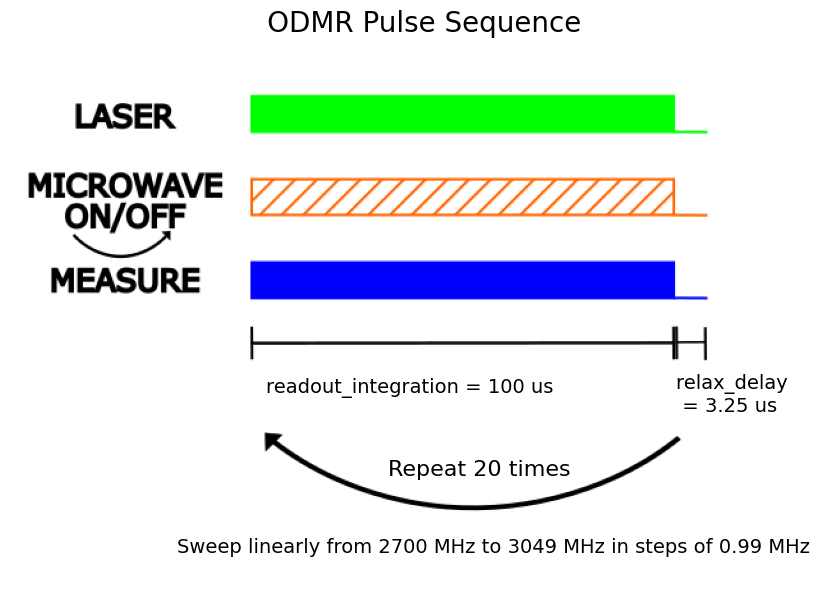

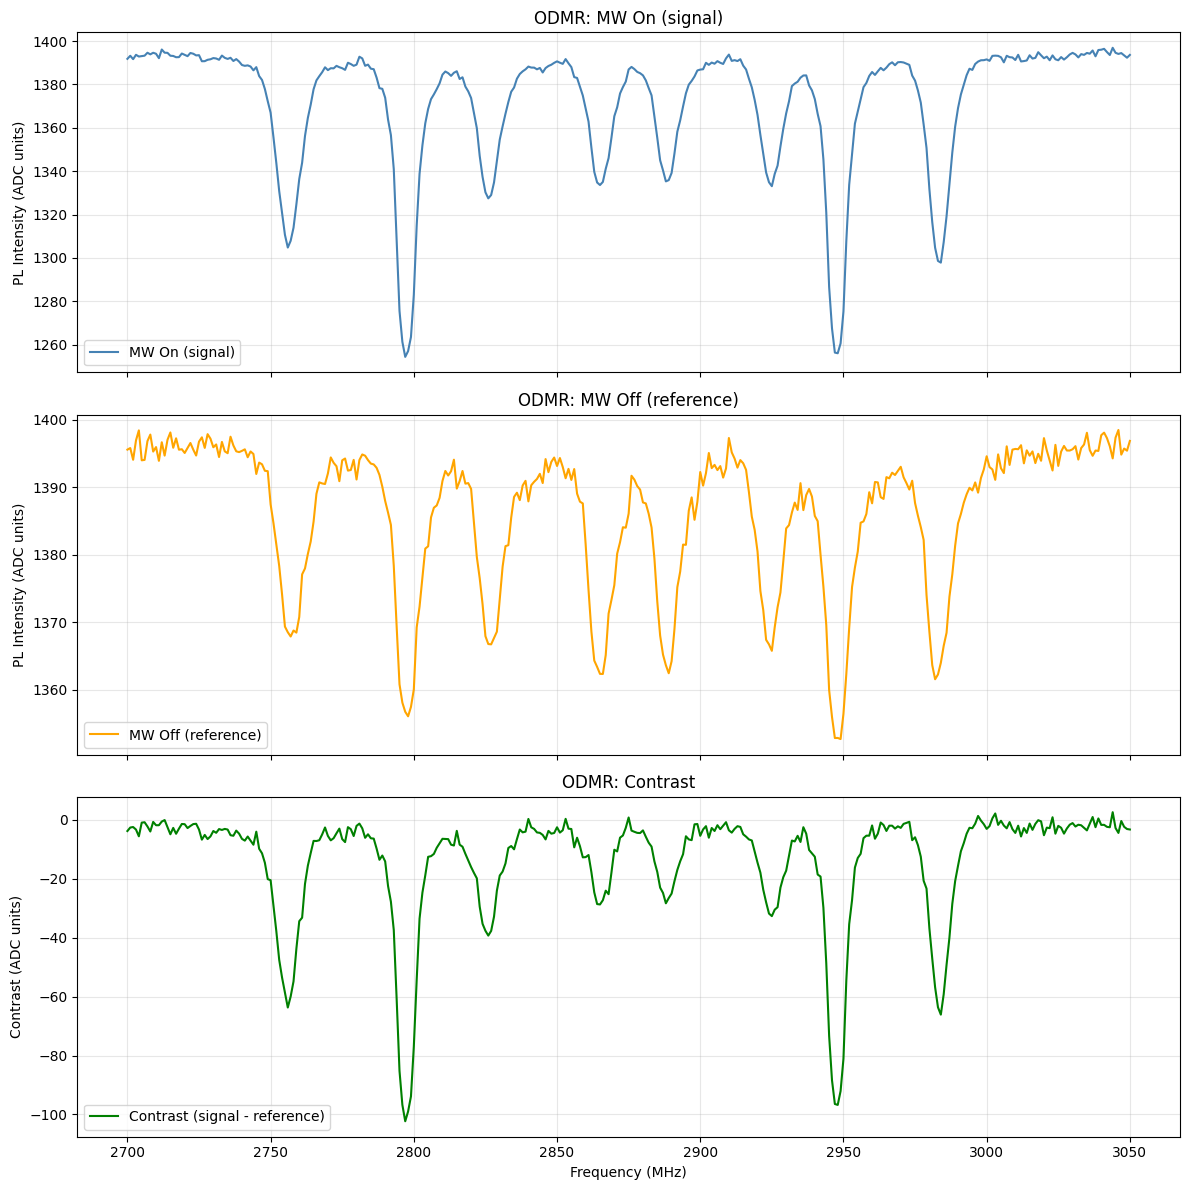

In [36]:
qd.LockinODMR.plot_sequence(config_odmr)

# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(d.frequencies, d.contrast, label='Contrast (signal - reference)', color='green')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Two-point lock-in

## Step 1a - Pick the single best peak to track

Every transition in the sweep is fitted, then scored on three things:

* **Pronounced** - dip depth divided by the local high-frequency noise sigma (SNR).
  Deeper dip -> steeper flanks -> more Hz of peak shift per ADC count.
* **Symmetric** - the left and right half-depth half-widths must match, and the two flank
  slopes must match in magnitude. Asymmetry (unresolved hyperfine, an overlapping
  neighbour, a sloping baseline) biases the two-point inversion, because both methods
  assume the same lineshape on either side of `f0`.
* **Well fitted** - RMS residual of a single-Lorentzian fit, relative to the dip depth. A
  poor fit means the single-Lorentzian model the inversion relies on is wrong here.

Four conditions are hard filters rather than scores, and a candidate failing any of them
is listed with its `reject_reason`:

* **Isolation** from the nearest other transition, in units of the peak's own linewidth
  (`MIN_ISOLATION_FWHM`) - a 14 MHz-wide line needs far more room than a 2 MHz one. If a
  neighbour sits inside the fit window, the flank the tracker parks on is not the flank
  the calibration measured.
* **Resolution** - at least `MIN_POINTS_PER_FWHM` sweep points across the linewidth. Every
  kHz this notebook reports is scaled by that linewidth, and a linewidth cannot be measured
  from a sweep that barely samples it.
* **The fit converged** - `gamma` must not sit on either bound.
* **`f0` is actually inside a dip** - if the half-depth crossings are undefined, the
  detector collapsed a hyperfine pair and fitted the bump between its components.

If nothing survives, the cell **raises** with the per-candidate reasons and the sweep step
you would need instead, rather than quietly calibrating on a bad peak. Setting
`FORCE_PEAK_CENTER_MHZ` overrides that and proceeds anyway.

The Lorentzian fit runs **twice**: once in the detection window `FIT_WINDOW_MHZ`, then
again in a window scaled to the linewidth that first pass measured
(`PEAK_FIT_WINDOW_FACTOR x FWHM`, clipped so it cannot swallow a neighbour). Without the
second pass a line much broader than `FIT_WINDOW_MHZ` is fitted over a nearly straight
slice of its own flank, and both the FWHM and the parked placement come out wrong.

Set `FORCE_PEAK_CENTER_MHZ` to override the automatic choice. Step 1b then places the
parked pair on whichever peak this cell selected.

In [37]:
# Step 1a - Choose ONE peak to track.
#
# Difference from Lockin_module: that notebook parks 16 frequencies (8 transitions x 2
# flanks) so nv_toolkit can reconstruct a full B vector. Here we park TWO frequencies on
# ONE transition. That tracks the shift of that resonance -- the field projection along
# that NV axis -- but is NOT enough for a vector reconstruction, so no reconstruction
# cell exists in this notebook.
#
# Candidate detection reuses the same nv_toolkit pipeline as Lockin_module
# (detect -> cluster -> collapse -> local fit -> pair rejection); only the selection,
# the linewidth-scaled refit and the placement that follow are new.
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import FileLink, display

# ------------------------------------------------------------------ knobs ---
ODMR_CSV_OVERRIDE = None        # Path("...odmr_sweep_....csv") to analyse a saved sweep

# Candidate detection (same values as Lockin_module).
SNR_THRESHOLD         = 0.8
CLUSTER_MERGE_MHZ     = 3.0
FIT_WINDOW_MHZ        = 8.0     # detection-stage window; the refit below rescales it
MAX_CENTERS           = 8
REQUIRE_PAIRED_PEAKS  = True    # drop fitted dips with no 2870-mirrored partner
PEAK_SEARCH_RANGE_MHZ = None    # e.g. (2820, 2920) to restrict where we look

# Second-pass fit and analysis windows, in units of the measured FWHM.
PEAK_FIT_WINDOW_FACTOR = 3.0    # full refit window = factor x FWHM
SLOPE_SEARCH_FWHM      = 1.5    # flank max-slope search half-width = this x FWHM

# Peak scoring (weights need not sum to 1; they are renormalised).
W_PROMINENCE       = 0.45
W_SYMMETRY         = 0.40
W_FIT              = 0.15
MIN_SNR            = 3.0        # reject candidates shallower than this
MIN_ISOLATION_MHZ  = 5.0        # absolute floor on the distance to the nearest neighbour
MIN_ISOLATION_FWHM = 1.5        # ... and at least this many of the peak's own linewidths
MIN_POINTS_PER_FWHM = 4.0       # the sweep must resolve the line this well to calibrate it
FIT_RESID_SCALE    = 0.10       # residual/depth that halves the fit sub-score

# Manual override: a frequency in MHz forces which peak is tracked (nearest candidate).
FORCE_PEAK_CENTER_MHZ = None

# ------------------------------------------------------- nv_toolkit import ---
_search_roots = [Path.cwd(), *Path.cwd().parents]
NV_REPO_DIR = None
for _root in _search_roots:
    candidate = _root / "NV_Magnetometry_Software-main"
    if (candidate / "nv_toolkit" / "operator_cli.py").exists():
        NV_REPO_DIR = candidate
        break
if NV_REPO_DIR is None:
    raise FileNotFoundError("NV_Magnetometry_Software-main not found relative to notebook directory")
if str(NV_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(NV_REPO_DIR))

from nv_toolkit.peaks import (
    detect_baseline_corrected_dip_candidates,
    cluster_dip_candidates,
    collapse_candidate_clusters,
    fit_local_dips,
    reject_unpaired_peaks,
)
from nv_toolkit.tui import _suggest_parked_frequencies

# ----------------------------------------------------------- load the sweep ---
if ODMR_CSV_OVERRIDE is not None:
    ODMR_CSV_FOR_PLAN = Path(ODMR_CSV_OVERRIDE)
elif "LAST_ODMR_CSV" in globals() and Path(LAST_ODMR_CSV).exists():
    ODMR_CSV_FOR_PLAN = Path(LAST_ODMR_CSV)
else:
    _odmr_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    _odmr_files = sorted(_odmr_dir.glob("odmr_sweep_*.csv"))
    if not _odmr_files:
        raise FileNotFoundError(f"No odmr_sweep_*.csv found in {_odmr_dir}")
    ODMR_CSV_FOR_PLAN = _odmr_files[-1]
print(f"Reference ODMR: {ODMR_CSV_FOR_PLAN}")

_odmr_df = pd.read_csv(ODMR_CSV_FOR_PLAN)
freqs_mhz = _odmr_df["frequency_MHz"].to_numpy(dtype=float)
_mw_on  = _odmr_df["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)
_mw_off = _odmr_df["photoluminescence_mw_off_ADC"].to_numpy(dtype=float)
_df_step_mhz = float(np.median(np.diff(freqs_mhz)))

# TWO normalisations, deliberately kept apart (same split as Lockin_module):
#   `measured`      = mw_on / |median(mw_on)|  -> dip DETECTION and fitting only.
#   `spectrum_norm` = mw_on / |median(mw_off)| -> CALIBRATION scale. It matches the live
#     per-point mw_on/|mw_off| ratio, so baselines and slopes live on the same scale as
#     the parked measurements. MW-off has no dips, so its MEDIAN is used rather than the
#     per-bin value, which would inject reference noise into the calibration slopes.
measured      = _mw_on / abs(float(np.nanmedian(_mw_on)))
spectrum_norm = _mw_on / abs(float(np.median(_mw_off)))

# ------------------------------------------------- candidate detection chain ---
candidates = detect_baseline_corrected_dip_candidates(
    freqs_mhz, measured, min_prominence_sigma=SNR_THRESHOLD,
)
clusters = cluster_dip_candidates(candidates, merge_distance_mhz=CLUSTER_MERGE_MHZ)
candidate_centers, _cluster_rows = collapse_candidate_clusters(clusters, max_centers=MAX_CENTERS)

if PEAK_SEARCH_RANGE_MHZ is not None:
    _lo, _hi = float(PEAK_SEARCH_RANGE_MHZ[0]), float(PEAK_SEARCH_RANGE_MHZ[1])
    _n_before = len(candidate_centers)
    candidate_centers = candidate_centers[(candidate_centers >= _lo) & (candidate_centers <= _hi)]
    print(f"Search restricted to {_lo:.0f}-{_hi:.0f} MHz: kept {len(candidate_centers)} of {_n_before} centers.")
    if len(candidate_centers) == 0:
        raise RuntimeError("No candidate centers remain after PEAK_SEARCH_RANGE_MHZ filtering.")

local_fits = fit_local_dips(
    freqs_mhz, measured, candidate_centers,
    window_mhz=FIT_WINDOW_MHZ, hyperfine_merge_mhz=0.0,
)
if REQUIRE_PAIRED_PEAKS:
    kept_fits, rejected_fits = reject_unpaired_peaks(
        local_fits, (float(np.nanmin(freqs_mhz)), float(np.nanmax(freqs_mhz))),
    )
    if not kept_fits:
        print("Pair rejection removed every peak; falling back to all fitted peaks "
              "(set REQUIRE_PAIRED_PEAKS = False to silence this).")
        kept_fits, rejected_fits = list(local_fits), []
else:
    kept_fits, rejected_fits = list(local_fits), []
kept_fits = sorted(kept_fits, key=lambda f: f.center_mhz)
if not kept_fits:
    raise RuntimeError("No fitted transitions to choose from.")

# All detected centers (kept + rejected) define isolation distances -- a rejected peak
# still contaminates a flank parked next to it.
_all_centers = np.sort(np.asarray(
    [f.center_mhz for f in kept_fits] + [f.center_mhz for f in rejected_fits], dtype=float
))

# --------------------------------------------------------------- lineshape ---
def lorentzian_dip(f, baseline, contrast, f0, gamma):
    """Single Lorentzian dip in the calibration (z) scale."""
    return baseline - contrast * gamma**2 / ((f - f0)**2 + gamma**2)


def noise_sigma(y):
    """Robust noise sigma from the MAD of SECOND differences.

    Second differences annihilate any linear ramp, so the estimate is not inflated by
    the broad dip flanks the way a first-difference estimate would be. For white noise
    var(d2) = 6 sigma^2, hence the sqrt(6).
    """
    d2 = np.diff(np.asarray(y, dtype=float), n=2)
    if d2.size < 3:
        return float("nan")
    mad = np.median(np.abs(d2 - np.median(d2)))
    return float(1.4826 * mad / np.sqrt(6.0))


def orientation(freqs, y, center, half_width):
    """+1 if the feature at `center` points DOWN in y, -1 if it points up.

    Homodyne ADC can come back negative, in which case dips point up in the raw
    normalised trace. Everything downstream works in z = orient * y, where the dip
    always points down and the Lorentzian model above applies verbatim.
    """
    m = np.abs(freqs - center) <= half_width
    if m.sum() < 5:
        return 1.0
    y_center = float(np.interp(center, freqs, y))
    return 1.0 if y_center < float(np.median(y[m])) else -1.0


def fit_peak_z(freqs, y, center_guess, window_mhz, orient=None):
    """Orientation-aware single-Lorentzian fit in the calibration scale.

    Returns a dict in z-space: baseline, contrast, f0, gamma, fwhm, rms_resid, orient.
    """
    half = 0.5 * float(window_mhz)
    if orient is None:
        orient = orientation(freqs, y, center_guess, half)
    m = np.abs(freqs - center_guess) <= half
    fw, zw = freqs[m], orient * y[m]
    if fw.size < 6:
        raise RuntimeError(f"Only {fw.size} points within +/-{half:.1f} MHz of {center_guess:.2f} MHz")

    span = float(fw.max() - fw.min())
    dfreq = float(np.median(np.diff(fw)))
    b0 = float(np.median(zw[zw >= np.percentile(zw, 60)]))
    depth0 = max(b0 - float(np.min(zw)), 1e-9)
    f0_0 = float(fw[np.argmin(zw)])
    _below = fw[zw < b0 - depth0 / 2]
    gamma0 = max(0.5 * float(_below.max() - _below.min()), dfreq) if _below.size >= 2 else 3 * dfreq
    z_range = max(float(zw.max() - zw.min()), 1e-9)

    p0 = [b0, depth0, f0_0, gamma0]
    bounds = (
        [b0 - 5 * z_range, 0.0,          fw.min(), dfreq / 4],
        [b0 + 5 * z_range, 20 * z_range, fw.max(), span],
    )
    popt, _ = curve_fit(lorentzian_dip, fw, zw, p0=p0, bounds=bounds, maxfev=20000)
    resid = zw - lorentzian_dip(fw, *popt)
    # A gamma sitting on either bound means the fit never converged on a real linewidth --
    # usually the sweep step is too coarse for the line, or the window caught no curvature.
    _g_lo, _g_hi = bounds[0][3], bounds[1][3]
    railed = bool(popt[3] <= _g_lo * 1.01 or popt[3] >= _g_hi * 0.99)
    return {
        "gamma_railed": railed,
        "orient":     float(orient),
        "baseline":   float(popt[0]),
        "contrast":   float(popt[1]),
        "f0_mhz":     float(popt[2]),
        "gamma_mhz":  float(popt[3]),
        "fwhm_mhz":   float(2 * popt[3]),
        "rms_resid":  float(np.sqrt(np.mean(resid**2))),
        "n_points":   int(fw.size),
        "window_mhz": float(window_mhz),
    }


def fit_peak_two_pass(freqs, y, center_guess, isolation_mhz):
    """Fit once in FIT_WINDOW_MHZ, then refit in a window scaled to the measured FWHM.

    A line much broader than FIT_WINDOW_MHZ is otherwise fitted over a nearly straight
    slice of its own flank, which lets (contrast, gamma) run off together. The refit
    window is clipped so it cannot reach the nearest neighbouring transition.
    """
    first = fit_peak_z(freqs, y, center_guess, FIT_WINDOW_MHZ)
    want = PEAK_FIT_WINDOW_FACTOR * first["fwhm_mhz"]
    cap = 1.8 * float(isolation_mhz) if np.isfinite(isolation_mhz) else np.inf
    window = float(np.clip(want, FIT_WINDOW_MHZ, cap))
    if abs(window - first["window_mhz"]) < 0.5 * _df_step_mhz:
        return first
    try:
        return fit_peak_z(freqs, y, first["f0_mhz"], window, orient=first["orient"])
    except Exception:
        return first


def half_depth_halfwidths(freqs, z, f0, baseline, depth):
    """Distance from f0 out to the half-depth crossing on each side (interpolated)."""
    target = baseline - 0.5 * depth
    i0 = int(np.argmin(np.abs(freqs - f0)))
    if not (z[i0] < target):        # f0 is not actually inside the dip
        return float("nan"), float("nan")

    def walk(step):
        i = i0
        for _ in range(freqs.size):
            j = i + step
            if j < 0 or j >= freqs.size:
                return float("nan")
            if z[j] >= target:
                if z[j] == z[i]:
                    return abs(float(freqs[j]) - f0)
                t = (target - z[i]) / (z[j] - z[i])
                return abs(float(freqs[i] + t * (freqs[j] - freqs[i])) - f0)
            i = j
        return float("nan")

    return walk(-1), walk(+1)


def flank_max_slopes(freqs, z, f0, half_width):
    """Empirical steepest-slope point and slope on each flank, within +/- half_width."""
    grad = np.gradient(z, freqs)
    out = {}
    for side, mask in (
        ("minus", (freqs < f0) & (freqs >= f0 - half_width)),
        ("plus",  (freqs > f0) & (freqs <= f0 + half_width)),
    ):
        if mask.sum() < 2:
            out[side] = (float("nan"), float("nan"))
            continue
        idx = np.flatnonzero(mask)[int(np.argmax(np.abs(grad[mask])))]
        out[side] = (float(freqs[idx]), float(grad[idx]))
    return out

# ------------------------------------------------------------ score candidates ---
_sigma_global = noise_sigma(spectrum_norm)
score_rows = []
fit_cache = {}
for fit in kept_fits:
    center = float(fit.center_mhz)
    others = _all_centers[np.abs(_all_centers - center) > 1e-6]
    isolation = float(np.min(np.abs(others - center))) if others.size else float("inf")

    try:
        pk = fit_peak_two_pass(freqs_mhz, spectrum_norm, center, isolation)
    except Exception as exc:
        print(f"  {center:8.2f} MHz: Lorentzian fit failed ({exc}) - skipped")
        continue
    fit_cache[center] = pk

    z = pk["orient"] * spectrum_norm
    depth = pk["contrast"]
    snr = depth / _sigma_global if _sigma_global > 0 else float("nan")

    w_left, w_right = half_depth_halfwidths(freqs_mhz, z, pk["f0_mhz"], pk["baseline"], depth)
    if np.isfinite(w_left) and np.isfinite(w_right) and (w_left + w_right) > 0:
        asym_width = abs(w_left - w_right) / (w_left + w_right)
    else:
        asym_width = 1.0

    slope_half = max(SLOPE_SEARCH_FWHM * pk["fwhm_mhz"], 3 * _df_step_mhz)
    slopes = flank_max_slopes(freqs_mhz, z, pk["f0_mhz"], slope_half)
    m_l, m_r = abs(slopes["minus"][1]), abs(slopes["plus"][1])
    asym_slope = abs(m_l - m_r) / (m_l + m_r) if np.isfinite(m_l + m_r) and (m_l + m_r) > 0 else 1.0

    sym_score = 1.0 - 0.5 * (min(asym_width, 1.0) + min(asym_slope, 1.0))
    fit_score = 1.0 / (1.0 + (pk["rms_resid"] / depth) / FIT_RESID_SCALE) if depth > 0 else 0.0

    points_per_fwhm = pk["fwhm_mhz"] / _df_step_mhz if _df_step_mhz > 0 else np.inf
    reasons = []
    if not (np.isfinite(w_left) and np.isfinite(w_right)):
        reasons.append("f0 not inside a dip (fit landed between components?)")
    if pk["gamma_railed"]:
        reasons.append("linewidth railed on a fit bound")
    if points_per_fwhm < MIN_POINTS_PER_FWHM:
        reasons.append(f"only {points_per_fwhm:.1f} sweep points per FWHM")
    if snr < MIN_SNR:
        reasons.append(f"SNR {snr:.1f} < {MIN_SNR}")

    score_rows.append({
        "center_mhz":     pk["f0_mhz"],
        "points_per_fwhm": points_per_fwhm,
        "reject_reason":  "; ".join(reasons),
        "fwhm_mhz":       pk["fwhm_mhz"],
        "fit_window_mhz": pk["window_mhz"],
        "depth":          depth,
        "snr":            snr,
        "isolation_mhz":  isolation,
        "halfwidth_left_mhz":  w_left,
        "halfwidth_right_mhz": w_right,
        "asym_width":     asym_width,
        "asym_slope":     asym_slope,
        "rms_resid_rel":  pk["rms_resid"] / depth if depth > 0 else np.inf,
        "sym_score":      sym_score,
        "fit_score":      fit_score,
        "detect_center_mhz": center,
    })

if not score_rows:
    raise RuntimeError("Every candidate failed the Lorentzian fit -- check the sweep range/step.")

df_scores = pd.DataFrame(score_rows)
_snr_max = float(df_scores["snr"].max())
df_scores["prom_score"] = df_scores["snr"] / _snr_max if _snr_max > 0 else 0.0
_wsum = W_PROMINENCE + W_SYMMETRY + W_FIT
df_scores["total_score"] = (
    W_PROMINENCE * df_scores["prom_score"]
    + W_SYMMETRY * df_scores["sym_score"]
    + W_FIT * df_scores["fit_score"]
) / _wsum
df_scores["isolation_needed_mhz"] = np.maximum(
    MIN_ISOLATION_MHZ, MIN_ISOLATION_FWHM * df_scores["fwhm_mhz"])
df_scores["eligible"] = (
    (df_scores["reject_reason"] == "")
    & (df_scores["isolation_mhz"] >= df_scores["isolation_needed_mhz"])
)
df_scores.loc[
    (df_scores["reject_reason"] == "")
    & (df_scores["isolation_mhz"] < df_scores["isolation_needed_mhz"]),
    "reject_reason",
] = "neighbour too close"
df_scores = df_scores.sort_values("total_score", ascending=False).reset_index(drop=True)

_eligible = df_scores[df_scores["eligible"]]
if _eligible.empty:
    _narrowest = float(df_scores["fwhm_mhz"].min())
    _msg = [
        "No candidate is usable for a two-point calibration. Per-candidate reasons:",
        *(f"    {r.center_mhz:9.3f} MHz : {r.reject_reason}" for r in df_scores.itertuples()),
        "",
        f"Sweep step is {_df_step_mhz:.3f} MHz and the narrowest fitted linewidth is "
        f"{_narrowest:.3f} MHz.",
    ]
    if _narrowest / _df_step_mhz < MIN_POINTS_PER_FWHM:
        _msg.append(
            f"    -> Re-run the ODMR sweep with MW_FREQ_STEP_MHZ <= "
            f"{_narrowest / MIN_POINTS_PER_FWHM:.2f} MHz (narrow the range to keep it quick). "
            f"A linewidth cannot be calibrated from a sweep that barely samples it, and every "
            f"kHz this notebook reports is scaled by that linewidth."
        )
    _msg.append("    -> Or set FORCE_PEAK_CENTER_MHZ to proceed anyway, accepting the above.")
    if FORCE_PEAK_CENTER_MHZ is None:
        display(df_scores[["center_mhz", "fwhm_mhz", "points_per_fwhm", "snr",
                           "isolation_mhz", "total_score", "reject_reason"]].round(4))
        raise RuntimeError("\n".join(_msg))
    print("\n".join(_msg))
    _eligible = df_scores

if FORCE_PEAK_CENTER_MHZ is not None:
    _i = int(np.argmin(np.abs(df_scores["center_mhz"].to_numpy() - float(FORCE_PEAK_CENTER_MHZ))))
    chosen = df_scores.iloc[_i]
    print(f"FORCE_PEAK_CENTER_MHZ = {FORCE_PEAK_CENTER_MHZ} -> using the candidate at "
          f"{chosen['center_mhz']:.3f} MHz (rank {_i + 1} of {len(df_scores)}).")
else:
    chosen = _eligible.iloc[0]

CHOSEN_PEAK = fit_cache[float(chosen["detect_center_mhz"])]
Z_ORIENT = CHOSEN_PEAK["orient"]
z_ref = Z_ORIENT * spectrum_norm

print("\nCandidate ranking (higher total_score is better):")
display(df_scores[[
    "center_mhz", "fwhm_mhz", "points_per_fwhm", "snr", "isolation_mhz", "isolation_needed_mhz",
    "asym_width", "asym_slope", "rms_resid_rel", "prom_score", "sym_score", "fit_score",
    "total_score", "eligible", "reject_reason",
]].round(4))

Reference ODMR: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260817_140240.csv

Candidate ranking (higher total_score is better):


,center_mhz,fwhm_mhz,points_per_fwhm,snr,isolation_mhz,isolation_needed_mhz,asym_width,asym_slope,rms_resid_rel,prom_score,sym_score,fit_score,total_score,eligible,reject_reason
0,2797.4628,7.3620,7.3620,128.7416,28.8181,11.0431,0.0078,0.0803,0.0361,1.0000,0.9559,0.7350,0.9426,True,
1,2947.7408,6.7806,6.7806,124.0089,22.9050,10.1709,0.0020,0.0039,0.0647,0.9632,0.9971,0.6072,0.9234,True,
2,2983.4859,8.6204,8.6204,90.3753,35.7287,12.9307,0.0143,0.0763,0.0215,0.7020,0.9547,0.8230,0.8212,True,
3,2756.4033,10.1780,10.1780,82.4245,41.0652,15.2670,0.0145,0.0493,0.0204,0.6402,0.9681,0.8308,0.8000,True,
4,2826.2400,7.9576,7.9577,55.1638,28.8181,11.9365,0.0193,0.0638,0.0490,0.4285,0.9584,0.6711,0.6769,True,
5,2888.4553,6.3701,6.3701,45.9692,23.2785,9.5552,0.0268,0.0337,0.1737,0.3571,0.9698,0.3653,0.6034,True,
6,2865.2501,6.7516,6.7516,48.2974,23.2785,10.1273,0.0192,0.0902,0.1659,0.3751,0.9453,0.3761,0.6034,True,
7,2931.2336,78.0000,78.0000,97.6258,22.9050,117.0000,1.0000,0.4357,0.1458,0.7583,0.2822,0.4068,0.5151,False,f0 not inside a dip (fit landed between compon...


## Step 1b - Place the parked pair and build the calibration

Split from Step 1a so placement can be re-tuned - a different `PLACEMENT_MODE`, a manual
pair, a different peak via `FORCE_PEAK_CENTER_MHZ` - without re-running detection and
scoring on the whole sweep.

Placement puts the pair at the empirical steepest-slope point on each flank, symmetrised,
then (`BALANCE_PARKED_PAIR`) slides the pair as a unit onto the **balance point** - the
centre at which both flanks read the same normalised PL. That is the true zero of the
two-point discriminator. On a real, slightly asymmetric line it sits a few tens of kHz off
the fitted Lorentzian centre, and parking symmetrically about the fit instead leaves a
constant offset in the error signal.

The cell ends by building `TWOPOINT_CALIB` - `f0`, `FWHM`, contrast, baseline, the two
parked frequencies and their measured baselines/slopes - plus the three conversion helpers
(documented in Step 3) that every later cell consumes.


Tracked peak:  f0 = 2797.4628 MHz,  FWHM = 7.3620 MHz,  contrast = 0.10892,  SNR = 128.7
Fit:           window 42.0 MHz (42 points), residual 3.927e-03 (3.6% of depth)
Symmetry:      half-widths L/R = 3.819 / 3.760 MHz  (asym 0.008), slope asym 0.080
Placement:     symmetric_max_slope  ->  f- = 2793.9034 MHz, f+ = 2800.9034 MHz (spacing +/-3.5000 MHz = 0.48 FWHM)
Balance:       pair centred -59.4 kHz from the fitted f0, where both flanks read the same z (residual imbalance -1.22e-15)
Flank slopes:  m- = -0.022903 /MHz,  m+ = +0.019863 /MHz  (denominator m- - m+ = -0.042766)
Linear-method scale: 1e-4 in (z+ - z-) -> 2.34 kHz of peak shift

Calibration JSON: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_calibration_odmr_sweep_20260817_140240.json
Parked plan CSV:  /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_calibration_odmr_sweep_20260817_140240.json

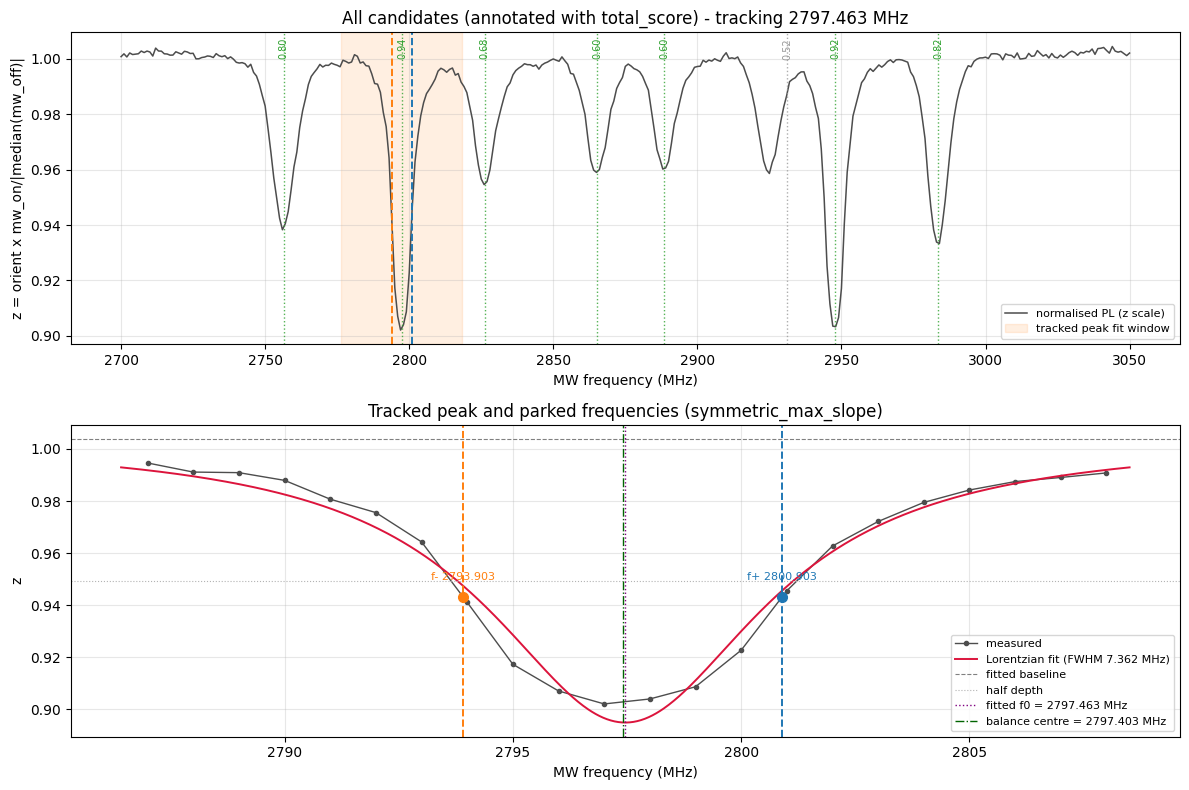

In [38]:
# Step 1b - Place the two parked frequencies and build TWOPOINT_CALIB.
# Consumes CHOSEN_PEAK / z_ref / freqs_mhz from Step 1a; re-runnable on its own after
# changing any knob below.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "CHOSEN_PEAK" not in globals():
    raise RuntimeError("Run Step 1a first -- it selects the peak this cell calibrates.")

# Parked-frequency placement on the chosen peak:
#   "symmetric_max_slope"  - empirical max |dz/df| per flank, then symmetrised (default)
#   "symmetric_half_max"   - f0 +/- FWHM/2
#   "lorentzian_max_slope" - f0 +/- gamma/sqrt(3) (analytic Lorentzian max-slope point)
#   "toolkit"              - nv_toolkit _suggest_parked_frequencies (Lockin_module rule)
#   "manual"               - use PARKED_MANUAL_MHZ
PLACEMENT_MODE    = "symmetric_max_slope"
PARKED_MANUAL_MHZ = None        # (f_minus, f_plus) when PLACEMENT_MODE == "manual"
# Slide the pair (keeping its spacing) onto the measured balance point, where the two
# flanks read the same z. That is the true zero of the two-point discriminator; the fitted
# Lorentzian center is generally a few tens of kHz away from it on real, slightly
# asymmetric lines. Ignored for PLACEMENT_MODE == "manual".
BALANCE_PARKED_PAIR = True

# NV gyromagnetic ratio, used only to quote a peak shift as an equivalent field
# projection along the tracked NV axis. This is NOT |B|.
# 28.024 GHz/T = 28.024e-3 MHz/uT, so delta_f[MHz] / this = shift in microtesla.
GAMMA_NV_MHZ_PER_UT = 28.024e-3

# -------------------------------------------------- place the two parked freqs ---
f0 = CHOSEN_PEAK["f0_mhz"]
gamma = CHOSEN_PEAK["gamma_mhz"]
PEAK_WINDOW_HALF_MHZ = max(SLOPE_SEARCH_FWHM * CHOSEN_PEAK["fwhm_mhz"], 3 * _df_step_mhz)
_slopes = flank_max_slopes(freqs_mhz, z_ref, f0, PEAK_WINDOW_HALF_MHZ)

if PLACEMENT_MODE == "manual":
    if PARKED_MANUAL_MHZ is None:
        raise ValueError('PLACEMENT_MODE == "manual" requires PARKED_MANUAL_MHZ = (f_minus, f_plus)')
    f_minus, f_plus = sorted(float(v) for v in PARKED_MANUAL_MHZ)
elif PLACEMENT_MODE == "symmetric_half_max":
    f_minus, f_plus = f0 - gamma, f0 + gamma
elif PLACEMENT_MODE == "lorentzian_max_slope":
    _delta = gamma / np.sqrt(3.0)
    f_minus, f_plus = f0 - _delta, f0 + _delta
elif PLACEMENT_MODE == "symmetric_max_slope":
    _d_minus = abs(f0 - _slopes["minus"][0])
    _d_plus = abs(_slopes["plus"][0] - f0)
    _delta = float(np.nanmean([_d_minus, _d_plus]))
    if not np.isfinite(_delta) or _delta <= 0:
        _delta = gamma / np.sqrt(3.0)
        print("  Empirical max-slope search failed; fell back to gamma/sqrt(3).")
    f_minus, f_plus = f0 - _delta, f0 + _delta
elif PLACEMENT_MODE == "toolkit":
    _plan = _suggest_parked_frequencies(freqs_mhz, measured, np.asarray([f0]), placement="auto")
    f_minus = float(_plan[0].frequency_minus_mhz)
    f_plus = float(_plan[0].frequency_plus_mhz)
else:
    raise ValueError(f"Unknown PLACEMENT_MODE: {PLACEMENT_MODE!r}")

# Slide the pair onto the measured balance point (z equal on both flanks), keeping the
# spacing. Solved by bisection on the sign change of the imbalance, searched within half
# the parked spacing of f0 so it cannot wander onto a neighbouring feature.
BALANCE_OFFSET_MHZ = 0.0
if BALANCE_PARKED_PAIR and PLACEMENT_MODE != "manual":
    _delta = 0.5 * (f_plus - f_minus)
    _cs = np.linspace(f0 - _delta, f0 + _delta, 4001)
    _imb = (np.interp(_cs - _delta, freqs_mhz, z_ref)
            - np.interp(_cs + _delta, freqs_mhz, z_ref))
    _sc = np.flatnonzero(np.sign(_imb[:-1]) != np.sign(_imb[1:]))
    if _sc.size:
        _i = int(_sc[np.argmin(np.abs(_cs[_sc] - f0))])
        _t = _imb[_i] / (_imb[_i] - _imb[_i + 1])
        _c_bal = float(_cs[_i] + _t * (_cs[_i + 1] - _cs[_i]))
        BALANCE_OFFSET_MHZ = _c_bal - f0
        f_minus, f_plus = _c_bal - _delta, _c_bal + _delta
    else:
        print("  Balance point not bracketed within +/- one parked spacing of f0; "
              "leaving the pair centred on the fitted f0.")

# Measured baselines and slopes at the parked points, in the calibration (z) scale.
_grad_z = np.gradient(z_ref, freqs_mhz)
baseline_minus = float(np.interp(f_minus, freqs_mhz, z_ref))
baseline_plus  = float(np.interp(f_plus,  freqs_mhz, z_ref))
slope_minus    = float(np.interp(f_minus, freqs_mhz, _grad_z))
slope_plus     = float(np.interp(f_plus,  freqs_mhz, _grad_z))

TWOPOINT_CALIB = {
    "odmr_csv":              str(ODMR_CSV_FOR_PLAN),
    "orient":                float(Z_ORIENT),
    "f0_mhz":                float(f0),
    "gamma_mhz":             float(gamma),
    "fwhm_mhz":              float(CHOSEN_PEAK["fwhm_mhz"]),
    "contrast":              float(CHOSEN_PEAK["contrast"]),
    "baseline_fit":          float(CHOSEN_PEAK["baseline"]),
    "rms_resid":             float(CHOSEN_PEAK["rms_resid"]),
    "fit_window_mhz":        float(CHOSEN_PEAK["window_mhz"]),
    "f_minus_mhz":           float(f_minus),
    "f_plus_mhz":            float(f_plus),
    "baseline_minus":        baseline_minus,
    "baseline_plus":         baseline_plus,
    "slope_minus_per_mhz":   slope_minus,
    "slope_plus_per_mhz":    slope_plus,
    "placement_mode":        PLACEMENT_MODE,
    "balance_offset_mhz":    float(BALANCE_OFFSET_MHZ),
    "snr":                   float(chosen["snr"]),
    "total_score":           float(chosen["total_score"]),
    "gamma_nv_mhz_per_uT":   float(GAMMA_NV_MHZ_PER_UT),
    # Constant used to put raw live ADC counts on the calibration z scale when no
    # per-shot reference is taken (TWOPOINT_SKIP_REFERENCE). It is exactly the divisor
    # Step 1a used to build spectrum_norm, so both live on the same scale.
    "ref_norm_counts":       float(abs(np.median(_mw_off))),
}

TWOPOINT_FREQS_MHZ = np.asarray([f_minus, f_plus], dtype=float)

# The parked frequencies must straddle f0 with slopes of opposite sign, or neither
# conversion method has a stable inverse.
assert f_minus < f0 < f_plus, (
    f"Parked frequencies must straddle f0: {f_minus:.3f} < {f0:.3f} < {f_plus:.3f} failed"
)
if not (slope_minus < 0 < slope_plus):
    print(f"WARNING: expected slope_minus < 0 < slope_plus in z-space, got "
          f"{slope_minus:+.4g} and {slope_plus:+.4g}. The parked points may be outside the "
          f"dip, or the peak is contaminated by a neighbour.")

# ------------------------------------------------------- conversion helpers ---
# Defined here because they are pure functions of TWOPOINT_CALIB; the maths is documented
# in the Step 3 markdown. Step 3 onwards just calls them.
#
# Only the slope-based estimator is used -- the same expression Lockin_module runs on each
# of its 8 blocks (nv_toolkit.two_point.estimate_delta_f_mhz). An exact Lorentzian
# depth-ratio inversion used to live here too; it was removed because it divides by the
# dip-depth ratio, which is ill-conditioned whenever a flank sits near the baseline, and
# it produced NaNs and multi-MHz spikes on real data while this estimator stayed clean.

def twopoint_z_from_counts(signal_counts, reference_counts=None, calib=None):
    """Raw ADC counts -> calibration-scale z.

    With a per-shot reference, divide by |reference| (not reference) so dips point the
    same way for positive PL and negative homodyne ADC -- the same convention as
    nv_toolkit.two_point.normalised_signal_from_counts, plus the orientation factor.

    With reference_counts=None (TWOPOINT_SKIP_REFERENCE, where the MW cannot truly be
    gated off so an "MW-off" shot is not a clean normaliser) divide by the constant
    captured at calibration time instead. A multiplicative drift in laser power then
    scales z_plus and z_minus together, and since the estimator uses their DIFFERENCE --
    which is ~0 for a balanced pair -- it largely cancels anyway. What does not cancel is
    a constant offset, which is why the live cell auto-zeros.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    if reference_counts is None:
        norm = float(calib["ref_norm_counts"])
    else:
        norm = np.abs(np.asarray(reference_counts, dtype=float))
        if np.any(norm == 0):
            raise ValueError("reference_counts must be non-zero")
    return float(calib["orient"]) * np.asarray(signal_counts, dtype=float) / norm


def twopoint_delta_f_linear(z_minus, z_plus, calib=None, zero_lockin=None):
    """Slope-based df -- same formula as nv_toolkit.two_point.estimate_delta_f_mhz.

    zero_lockin overrides the reference value of (z_plus - z_minus) that counts as zero
    shift. It defaults to the calibration's (b_plus - b_minus) from the ODMR sweep; the
    live cell passes its auto-zero instead, which is what removes the constant offset
    introduced by dropping the per-shot reference.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    denom = float(calib["slope_minus_per_mhz"]) - float(calib["slope_plus_per_mhz"])
    if abs(denom) < 1e-12:
        raise ValueError("Calibration slopes are too small for a stable delta_f estimate")
    if zero_lockin is None:
        zero_lockin = float(calib["baseline_plus"]) - float(calib["baseline_minus"])
    d_current = np.asarray(z_plus, dtype=float) - np.asarray(z_minus, dtype=float)
    return (d_current - float(zero_lockin)) / denom


# --------------------------------------------------------------- persist -----
TWOPOINT_DIR = PROJECT_ROOT / "data" / "twopoint_lockin"
TWOPOINT_DIR.mkdir(parents=True, exist_ok=True)
TWOPOINT_CALIB_JSON = TWOPOINT_DIR / f"twopoint_calibration_{ODMR_CSV_FOR_PLAN.stem}.json"
TWOPOINT_CALIB_JSON.write_text(json.dumps(TWOPOINT_CALIB, indent=2), encoding="utf-8")

TWOPOINT_PLAN_CSV = TWOPOINT_DIR / f"twopoint_plan_{ODMR_CSV_FOR_PLAN.stem}.csv"
pd.DataFrame([
    {"point_index": 1, "point_in_block": 0, "label": "f_minus", "frequency_mhz": f_minus,
     "baseline_z": baseline_minus, "slope_z_per_mhz": slope_minus},
    {"point_index": 2, "point_in_block": 1, "label": "f_plus", "frequency_mhz": f_plus,
     "baseline_z": baseline_plus, "slope_z_per_mhz": slope_plus},
]).to_csv(TWOPOINT_PLAN_CSV, index=False)

_denom = slope_minus - slope_plus
print(f"\nTracked peak:  f0 = {f0:.4f} MHz,  FWHM = {CHOSEN_PEAK['fwhm_mhz']:.4f} MHz,  "
      f"contrast = {CHOSEN_PEAK['contrast']:.5f},  SNR = {chosen['snr']:.1f}")
print(f"Fit:           window {CHOSEN_PEAK['window_mhz']:.1f} MHz "
      f"({CHOSEN_PEAK['n_points']} points), residual {CHOSEN_PEAK['rms_resid']:.3e} "
      f"({100 * CHOSEN_PEAK['rms_resid'] / CHOSEN_PEAK['contrast']:.1f}% of depth)")
print(f"Symmetry:      half-widths L/R = {chosen['halfwidth_left_mhz']:.3f} / "
      f"{chosen['halfwidth_right_mhz']:.3f} MHz  (asym {chosen['asym_width']:.3f}), "
      f"slope asym {chosen['asym_slope']:.3f}")
print(f"Placement:     {PLACEMENT_MODE}  ->  f- = {f_minus:.4f} MHz, f+ = {f_plus:.4f} MHz "
      f"(spacing +/-{0.5 * (f_plus - f_minus):.4f} MHz = {0.5*(f_plus-f_minus)/CHOSEN_PEAK['fwhm_mhz']:.2f} FWHM)")
if BALANCE_PARKED_PAIR and PLACEMENT_MODE != "manual":
    print(f"Balance:       pair centred {BALANCE_OFFSET_MHZ*1e3:+.1f} kHz from the fitted f0, "
          f"where both flanks read the same z (residual imbalance "
          f"{baseline_plus - baseline_minus:+.2e})")
print(f"Flank slopes:  m- = {slope_minus:+.5g} /MHz,  m+ = {slope_plus:+.5g} /MHz  "
      f"(denominator m- - m+ = {_denom:+.5g})")
print(f"Linear-method scale: 1e-4 in (z+ - z-) -> {abs(1e-4 / _denom) * 1e3:.2f} kHz of peak shift")
print(f"\nCalibration JSON: {TWOPOINT_CALIB_JSON}")
print(f"Parked plan CSV:  {TWOPOINT_PLAN_CSV}")
display(FileLink(str(TWOPOINT_CALIB_JSON)))

# ------------------------------------------------------------------ plots ----
fig, (ax_all, ax_zoom) = plt.subplots(2, 1, figsize=(12, 8))

ax_all.plot(freqs_mhz, z_ref, color="0.3", lw=1.1, label="normalised PL (z scale)")
for _, r in df_scores.iterrows():
    _c = "tab:green" if r["eligible"] else "0.6"
    ax_all.axvline(r["center_mhz"], color=_c, ls=":", lw=1.0, alpha=0.8)
    ax_all.annotate(f"{r['total_score']:.2f}", xy=(r["center_mhz"], 1.0),
                    xycoords=("data", "axes fraction"),
                    xytext=(0, -4), textcoords="offset points", ha="center", va="top",
                    fontsize=7, color=_c, rotation=90)
ax_all.axvspan(f0 - CHOSEN_PEAK["window_mhz"] / 2, f0 + CHOSEN_PEAK["window_mhz"] / 2,
               color="tab:orange", alpha=0.12, label="tracked peak fit window")
ax_all.axvline(f_minus, color="tab:orange", ls="--", lw=1.4)
ax_all.axvline(f_plus,  color="tab:blue",   ls="--", lw=1.4)
ax_all.set(xlabel="MW frequency (MHz)", ylabel="z = orient x mw_on/|median(mw_off)|",
           title=f"All candidates (annotated with total_score) - tracking {f0:.3f} MHz")
ax_all.grid(True, alpha=0.3)
ax_all.legend(fontsize=8, loc="lower right")

_zoom_half = max(1.5 * CHOSEN_PEAK["fwhm_mhz"], 1.5 * (f_plus - f_minus))
_m = np.abs(freqs_mhz - f0) <= _zoom_half
_ffine = np.linspace(f0 - _zoom_half, f0 + _zoom_half, 800)
ax_zoom.plot(freqs_mhz[_m], z_ref[_m], "o-", ms=3, lw=1.0, color="0.3", label="measured")
ax_zoom.plot(_ffine, lorentzian_dip(_ffine, CHOSEN_PEAK["baseline"], CHOSEN_PEAK["contrast"],
                                    f0, gamma),
             color="crimson", lw=1.4,
             label=f"Lorentzian fit (FWHM {CHOSEN_PEAK['fwhm_mhz']:.3f} MHz)")
ax_zoom.axhline(CHOSEN_PEAK["baseline"], color="0.5", ls="--", lw=0.8, label="fitted baseline")
ax_zoom.axhline(CHOSEN_PEAK["baseline"] - 0.5 * CHOSEN_PEAK["contrast"], color="0.7", ls=":", lw=0.8,
                label="half depth")
ax_zoom.axvline(f0, color="purple", ls=":", lw=1.0, label=f"fitted f0 = {f0:.3f} MHz")
_c_mid = 0.5 * (f_minus + f_plus)
if abs(_c_mid - f0) > 1e-9:
    ax_zoom.axvline(_c_mid, color="darkgreen", ls="-.", lw=1.0,
                    label=f"balance centre = {_c_mid:.3f} MHz")
for _f, _b, _col, _lab in ((f_minus, baseline_minus, "tab:orange", "f-"),
                           (f_plus,  baseline_plus,  "tab:blue",   "f+")):
    ax_zoom.axvline(_f, color=_col, ls="--", lw=1.4)
    ax_zoom.plot([_f], [_b], "o", color=_col, ms=7, zorder=5)
    ax_zoom.annotate(f"{_lab} {_f:.3f}", xy=(_f, _b), xytext=(0, 12), textcoords="offset points",
                     ha="center", fontsize=8, color=_col)
ax_zoom.set(xlabel="MW frequency (MHz)", ylabel="z",
            title=f"Tracked peak and parked frequencies ({PLACEMENT_MODE})")
ax_zoom.grid(True, alpha=0.3)
ax_zoom.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

## Step 2 - One batch at the two parked frequencies

`MultipointLockinODMR` is generic in the number of frequencies, so the same single-program
upload used for 16 points works for 2. With only 2 points a batch is roughly 8x shorter
than the 16-point equivalent at the same `reps`, which is the whole reason for running a
single peak: the same averaging in an eighth of the time, or 8x the update rate at the
same noise.

This cell is the sanity check before going live - it confirms the parked ADC values land
on the ODMR flanks where Step 1 said they would.

Built single MultipointLockinODMR program for 2 frequencies (2793.903, 2800.903 MHz) in 0.00 s
Predicted time per batch: 2 ms (0.2 ms/rep x 10 reps)
Reference readout: SKIPPED (1 readout per frequency) -> 2 readouts per rep
batch 1/1: acquired in 12 ms (predicted ~2 ms)

Saved 1 batches to /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_lockin_collected.csv


,batch,time_s,timestamp_epoch_s,acq_seconds,peak_01,peak_01_freq_mhz,peak_02,peak_02_freq_mhz
0,0,0.012624,1.786993e+09,0.012203,1263.929262,2793.903382,1275.684947,2800.903379


/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_lockin_collected.csv

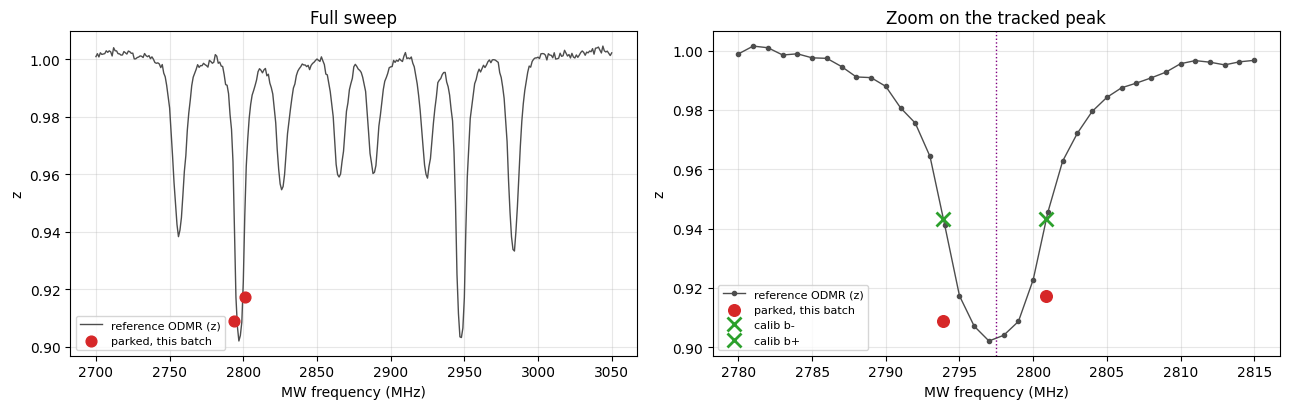

Parked z vs calibration baseline:  f- -0.03443   f+ -0.02598
Both offsets should be small and of comparable size. A large COMMON offset means the laser/MW level drifted since the ODMR sweep (harmless for the exact method, which cancels contrast, but it biases the linear method). A large DIFFERENTIAL offset is a genuine peak shift.


In [40]:
# Step 2 - Acquire the two parked frequencies in ONE FPGA program upload.
#
# DEFENSIVE GUARD (inherited from Lockin_module): the program is built ONCE before the
# batch loop. Each MultipointLockinODMR build is a ~300-500 ms FPGA upload, so rebuilding
# inside the loop is what made the old 8-peak cell take minutes.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

# notebook_modules/ is already on sys.path via the project_root_setup cell.
import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

if "TWOPOINT_FREQS_MHZ" not in globals():
    raise RuntimeError("Run Step 1 first -- it defines TWOPOINT_FREQS_MHZ and TWOPOINT_CALIB.")

# --- Acquisition parameters ---
TWOPOINT_REPS_PER_BATCH   = 10
TWOPOINT_N_BATCHES        = 1
TWOPOINT_OFF_RESONANCE_MHZ = 2700.0   # only used when TWOPOINT_SKIP_REFERENCE is False
TWOPOINT_RELAX_DELAY_TREG  = 1000     # laser repolarisation window inside each frequency block
# Drop the per-frequency reference readout. The MW cannot actually be gated off, so an
# "MW-off" shot is a contaminated copy of the signal rather than a clean normaliser --
# and taking it doubles the readouts per rep. With it skipped, z is formed against the
# constant TWOPOINT_CALIB["ref_norm_counts"] captured from the reference ODMR sweep.
TWOPOINT_SKIP_REFERENCE    = True
TWOPOINT_DATA_CSV = TWOPOINT_DIR / "twopoint_lockin_collected.csv"
TWOPOINT_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the two-point config ---
cfg = copy(default_config)
cfg.multipoint_freqs_mhz = list(TWOPOINT_FREQS_MHZ)
cfg.odmr_reference_offres_mhz = TWOPOINT_OFF_RESONANCE_MHZ
cfg.multipoint_skip_reference = bool(TWOPOINT_SKIP_REFERENCE)
cfg.relax_delay_treg = int(TWOPOINT_RELAX_DELAY_TREG)
# QickSweep needs a sweep definition even though we drive frequencies from body();
# a zero-span single point keeps the outer sweep trivial.
cfg.mw_start_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg.mw_end_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg.nsweep_points = 1
cfg.reps = int(TWOPOINT_REPS_PER_BATCH)
cfg.pre_init = getattr(default_config, "pre_init", True)

t_build_start = perf_counter()
prog = MultipointLockinODMR(cfg)
_build_seconds = perf_counter() - t_build_start
_predicted_ms_per_batch = prog.total_time() * 1e3
print(f"Built single MultipointLockinODMR program for {len(TWOPOINT_FREQS_MHZ)} frequencies "
      f"({TWOPOINT_FREQS_MHZ[0]:.3f}, {TWOPOINT_FREQS_MHZ[1]:.3f} MHz) in {_build_seconds:.2f} s")
print(f"Predicted time per batch: {_predicted_ms_per_batch:.0f} ms "
      f"({prog.time_per_rep()*1e3:.1f} ms/rep x {cfg.reps} reps)")
print(f"Reference readout: {'SKIPPED (1 readout per frequency)' if TWOPOINT_SKIP_REFERENCE else 'taken (2 readouts per frequency)'}"
      f" -> {len(TWOPOINT_FREQS_MHZ) * (1 if TWOPOINT_SKIP_REFERENCE else 2)} readouts per rep")

_first_batch_dt = None
rows = []
t0 = perf_counter()
for batch in range(int(TWOPOINT_N_BATCHES)):
    t_acq_start = perf_counter()
    d_batch = prog.acquire(progress=False)
    acq_dt = perf_counter() - t_acq_start
    if _first_batch_dt is None:
        _first_batch_dt = acq_dt

    row = {
        "batch": batch,
        "time_s": perf_counter() - t0,
        "timestamp_epoch_s": time(),
        "acq_seconds": acq_dt,
    }
    _refs = d_batch.reference if d_batch.reference is not None else [None] * len(d_batch.signal)
    for k, (freq_mhz, sig, ref) in enumerate(zip(d_batch.frequencies_mhz, d_batch.signal, _refs)):
        row[f"peak_{k+1:02d}"] = float(sig)
        if ref is not None:
            row[f"peak_{k+1:02d}_ref"] = float(ref)
        row[f"peak_{k+1:02d}_freq_mhz"] = float(freq_mhz)
    rows.append(row)
    print(f"batch {batch+1}/{int(TWOPOINT_N_BATCHES)}: acquired in {acq_dt*1000:.0f} ms "
          f"(predicted ~{_predicted_ms_per_batch:.0f} ms)")

df_twopoint = pd.DataFrame(rows)
df_twopoint.to_csv(TWOPOINT_DATA_CSV, index=False)
print(f"\nSaved {len(df_twopoint)} batches to {TWOPOINT_DATA_CSV}")

if _first_batch_dt * 1000 > _predicted_ms_per_batch * 5:
    print(f"WARNING: first batch took {_first_batch_dt*1000:.0f} ms vs predicted "
          f"{_predicted_ms_per_batch:.0f} ms. If this persists across runs, network/board "
          f"state is the likely cause.")

display(df_twopoint)
display(FileLink(str(TWOPOINT_DATA_CSV)))

# --- Overlay: do the parked ADC values land on the ODMR flanks? ---
_row = df_twopoint.iloc[0]
_pk_f = np.array([float(_row["peak_01_freq_mhz"]), float(_row["peak_02_freq_mhz"])])
_pk_s = np.array([float(_row["peak_01"]), float(_row["peak_02"])])
if "peak_01_ref" in df_twopoint.columns:
    _pk_r = np.array([float(_row["peak_01_ref"]), float(_row["peak_02_ref"])])
    _pk_z = TWOPOINT_CALIB["orient"] * _pk_s / np.abs(_pk_r)
else:
    _pk_z = TWOPOINT_CALIB["orient"] * _pk_s / float(TWOPOINT_CALIB["ref_norm_counts"])

_zoom_half = max(2.5 * TWOPOINT_CALIB["fwhm_mhz"], 1.5 * (TWOPOINT_CALIB["f_plus_mhz"] - TWOPOINT_CALIB["f_minus_mhz"]))
_m = np.abs(freqs_mhz - TWOPOINT_CALIB["f0_mhz"]) <= _zoom_half

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4.2))
ax_l.plot(freqs_mhz, TWOPOINT_CALIB["orient"] * spectrum_norm, color="0.3", lw=1.0,
          label="reference ODMR (z)")
ax_l.scatter(_pk_f, _pk_z, color="tab:red", s=60, zorder=5, label="parked, this batch")
ax_l.set(xlabel="MW frequency (MHz)", ylabel="z", title="Full sweep")
ax_l.grid(True, alpha=0.3); ax_l.legend(fontsize=8)

ax_r.plot(freqs_mhz[_m], (TWOPOINT_CALIB["orient"] * spectrum_norm)[_m], "o-", ms=3, lw=1.0,
          color="0.3", label="reference ODMR (z)")
ax_r.scatter(_pk_f, _pk_z, color="tab:red", s=70, zorder=5, label="parked, this batch")
for _f, _b, _lab in ((TWOPOINT_CALIB["f_minus_mhz"], TWOPOINT_CALIB["baseline_minus"], "calib b-"),
                     (TWOPOINT_CALIB["f_plus_mhz"],  TWOPOINT_CALIB["baseline_plus"],  "calib b+")):
    ax_r.plot([_f], [_b], "x", color="tab:green", ms=10, mew=2, zorder=6, label=_lab)
ax_r.axvline(TWOPOINT_CALIB["f0_mhz"], color="purple", ls=":", lw=1.0)
ax_r.set(xlabel="MW frequency (MHz)", ylabel="z", title="Zoom on the tracked peak")
ax_r.grid(True, alpha=0.3); ax_r.legend(fontsize=8)
plt.tight_layout()
plt.show()

_dz = _pk_z - np.array([TWOPOINT_CALIB["baseline_minus"], TWOPOINT_CALIB["baseline_plus"]])
print(f"Parked z vs calibration baseline:  f- {_dz[0]:+.5f}   f+ {_dz[1]:+.5f}")
print("Both offsets should be small and of comparable size. A large COMMON offset means "
      "the laser/MW level drifted since the ODMR sweep (harmless for the exact method, "
      "which cancels contrast, but it biases the linear method). A large DIFFERENTIAL "
      "offset is a genuine peak shift.")

## Step 3 - Two-point conversion: parked PL -> peak frequency

One estimator, the same one `Lockin_module.ipynb` runs on each of its 8 blocks
(`nv_toolkit.two_point.estimate_delta_f_mhz`). Working in the normalised,
orientation-corrected signal `z = orient x (signal / |reference|)`:

`df = [(z_plus - z_minus) - (b_plus - b_minus)] / (m_minus - m_plus)`

where `b` are the calibration baselines and `m` the flank slopes, both measured off the
reference ODMR sweep in Step 1b. It is zero by construction when the parked pair reads what
the sweep read, it cannot produce a NaN, and its noise is exactly
`sigma(z_plus - z_minus) / |m_minus - m_plus|` - linear in the measurement noise, with no
term that can blow up.

The shift is valid while it stays small compared to the linewidth. Past roughly half the
FWHM the flanks are no longer locally linear and the estimate compresses; the Step 4x
acquisition cells print the dip depth at each parked point so you can see when that
happens.

**Removed:** an exact Lorentzian depth-ratio inversion used to run alongside this as
"method A", carried over from the QDM-heart notebook. It inverts `d_minus / d_plus`, so it
divides by the dip depth at a parked point. On real data a flank sitting near the baseline
made that denominator straddle zero, which produced multi-MHz spikes and NaN gaps in the
peak-shift trace while this estimator stayed clean. `Lockin_module` never used it, and
neither does this notebook now.

`B_shift_uT` is `df / 28.024e-3 MHz/uT` - the field change projected on the tracked NV
axis, assuming the shift is Zeeman in origin. It is not `|B|`, and a temperature drift in
`D` would appear here too.

In [41]:
# Step 3 - Apply the two-point conversion to the Step 2 batch.
# twopoint_z_from_counts / twopoint_delta_f_linear are defined at the end of Step 1b (they
# are pure functions of TWOPOINT_CALIB); the maths is in the markdown above. Everything
# works in z = orient * signal / |reference|.
import numpy as np
import pandas as pd
from IPython.display import display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b first -- it defines TWOPOINT_CALIB and the conversion helpers.")
if "df_twopoint" not in globals():
    raise RuntimeError("Run Step 2 first -- it defines df_twopoint.")


def twopoint_rows_from_wide(df_wide, calib=None):
    """Wide peak_01/peak_02 frame -> per-batch peak-shift table.

    delta_f is referenced to the calibration state by construction: it is zero when the
    parked pair reads the same (b_plus - b_minus) the reference ODMR sweep did.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    # Reference columns are absent when the run skipped the reference readout; then z is
    # formed against the constant calib["ref_norm_counts"] instead.
    _r1 = df_wide["peak_01_ref"].to_numpy(float) if "peak_01_ref" in df_wide.columns else None
    _r2 = df_wide["peak_02_ref"].to_numpy(float) if "peak_02_ref" in df_wide.columns else None
    z_minus = twopoint_z_from_counts(df_wide["peak_01"].to_numpy(float), _r1, calib)
    z_plus = twopoint_z_from_counts(df_wide["peak_02"].to_numpy(float), _r2, calib)
    delta_f = twopoint_delta_f_linear(z_minus, z_plus, calib)
    out = pd.DataFrame({
        "batch":          df_wide["batch"].to_numpy() if "batch" in df_wide else np.arange(len(df_wide)),
        "time_s":         df_wide["time_s"].to_numpy(float) if "time_s" in df_wide else np.arange(len(df_wide), dtype=float),
        "z_minus":        z_minus,
        "z_plus":         z_plus,
        "lockin_signal":  z_plus - z_minus,
        "delta_f_mhz":    delta_f,
        "peak_shift_kHz": delta_f * 1e3,
        "f_new_mhz":      float(calib["f0_mhz"]) + delta_f,
        "B_shift_uT":     delta_f / float(calib["gamma_nv_mhz_per_uT"]),
    })
    return out


df_convert = twopoint_rows_from_wide(df_twopoint)
TWOPOINT_CONVERT_CSV = TWOPOINT_DATA_CSV.with_name("twopoint_lockin_peak_inference.csv")
df_convert.to_csv(TWOPOINT_CONVERT_CSV, index=False)

print(f"Tracked peak: f0 = {TWOPOINT_CALIB['f0_mhz']:.4f} MHz, "
      f"FWHM = {TWOPOINT_CALIB['fwhm_mhz']:.4f} MHz")
if "peak_01_ref" not in df_twopoint.columns:
    print("No per-shot reference in this batch, so z is formed against the constant "
          "ref_norm_counts. Expect a CONSTANT offset here -- the absolute PL level has moved "
          "since the sweep. Step 4's auto-zero removes it; this single-batch number is only "
          "meaningful as a sanity check that the parked points sit on the flanks.")
display(df_convert.round(6))
print(f"\nWrote {TWOPOINT_CONVERT_CSV}")

_last = df_convert.iloc[-1]
_fwhm_khz = TWOPOINT_CALIB["fwhm_mhz"] * 1e3
print(f"\nLatest batch: f_new = {_last['f_new_mhz']:.4f} MHz  "
      f"(shift {_last['peak_shift_kHz']:+.1f} kHz = {_last['B_shift_uT']:+.2f} uT along this NV axis, "
      f"{100 * abs(_last['peak_shift_kHz']) / _fwhm_khz:.1f}% of the linewidth)")
if abs(_last["peak_shift_kHz"]) > 0.5 * _fwhm_khz:
    print("The shift exceeds half the linewidth, which is past the linear range of this "
          "estimator -- re-run Steps 1a/1b so the parked pair straddles the peak again.")

Tracked peak: f0 = 2797.4628 MHz, FWHM = 7.3620 MHz
No per-shot reference in this batch, so z is formed against the constant ref_norm_counts. Expect a CONSTANT offset here -- the absolute PL level has moved since the sweep. Step 4's auto-zero removes it; this single-batch number is only meaningful as a sanity check that the parked points sit on the flanks.


,batch,time_s,z_minus,z_plus,lockin_signal,delta_f_mhz,peak_shift_kHz,f_new_mhz,B_shift_uT
0,0,0.012624,0.908902,0.917355,0.008454,-0.197671,-197.671083,2797.265119,-7.053636



Wrote /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_lockin_peak_inference.csv

Latest batch: f_new = 2797.2651 MHz  (shift -197.7 kHz = -7.05 uT along this NV axis, 2.7% of the linewidth)


## Step 4A — Normal (averaged) mode  ·  ~88 Hz

One `acquire()` call returns one averaged sample. **The rate is set by the host call, not
by the readout window**, which is the opposite of what this notebook said before
2026-08-16. Measured across three sessions:

| τ | reps | FPGA readout | fastest call | median period | rate |
|---|---|---|---|---|---|
| 213 µs | 23 | 9.80 ms | 10.2 ms | 11.38 ms | 87.5 Hz |
| 120 µs | 23 | 5.52 ms | 10.3 ms | 11.38 ms | 87.8 Hz |
| 120 µs | 10 | 2.40 ms | 10.1 ms | 11.34 ms | 86.8 Hz |

A 4× change in FPGA work moves the period by 0.04 ms. The FPGA runs *underneath* the host
round-trip rather than adding to it, so:

* **shortening τ cannot make this mode faster** — that is why the 213 → 120 µs change
  bought nothing;
* **averaging is free** up to the call floor. At τ = 120 µs, 42 reps fit in the same
  ~10 ms that 10 reps used, so the run on 2026-08-14 was leaving a factor of ~2 in σ on
  the table. `AVG_REPS_PER_BATCH = None` fills the budget automatically.

Use this mode when ~88 Hz is enough and you want the simplest, most reliable path — it is
the only one of the three with no open defect. For higher rates go to Step 4B or 4C.

**Watch out:** at 88 Hz the 60 Hz mains line aliases to ~27 Hz, landing in the middle of
the band where nothing can separate it from signal. Step 5A prints this warning.

Measuring the per-call host floor (about 0.3 s)...
  fastest call 9.08 ms, median 9.66 ms, jitter 1.07 ms (FPGA work in the probe: 0.24 ms)

2 freqs, order=forward (2 slots/rep), tau=120.0 us, 10 reps -> 240 us/rep, 2.40 ms FPGA work
  averaged mode: 2.40 ms of FPGA work hides under the 9.1 ms per-call floor (26% used) -> 97.5 Hz
  FREE AVERAGING: 37 reps also fit inside the floor. Raising 10 -> 37 costs no rate and buys up to 1.9x in sigma if the noise is white.
  burst/stream : 4167 Hz per rep (240 us cadence); the floor is paid once per burst instead of once per sample
Reference readout: SKIPPED   reps/batch: 10  (set by hand)

Priming spin polarization...
Auto-zero over 20 batches: removed a constant -161 kHz offset. Shifts are measured from the start of this run, not from the ODMR sweep.

Acquiring into twopoint_lockin_live_20260817_140131.csv ...
Stopped by user after 1279 batches.

Averaged run finished: 1279 samples in 12.4 s -> 103.3 Hz

Per-call timing (ms): fastest=8.72  med

/Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/twopoint_lockin/twopoint_lockin_live_20260817_140131.csv

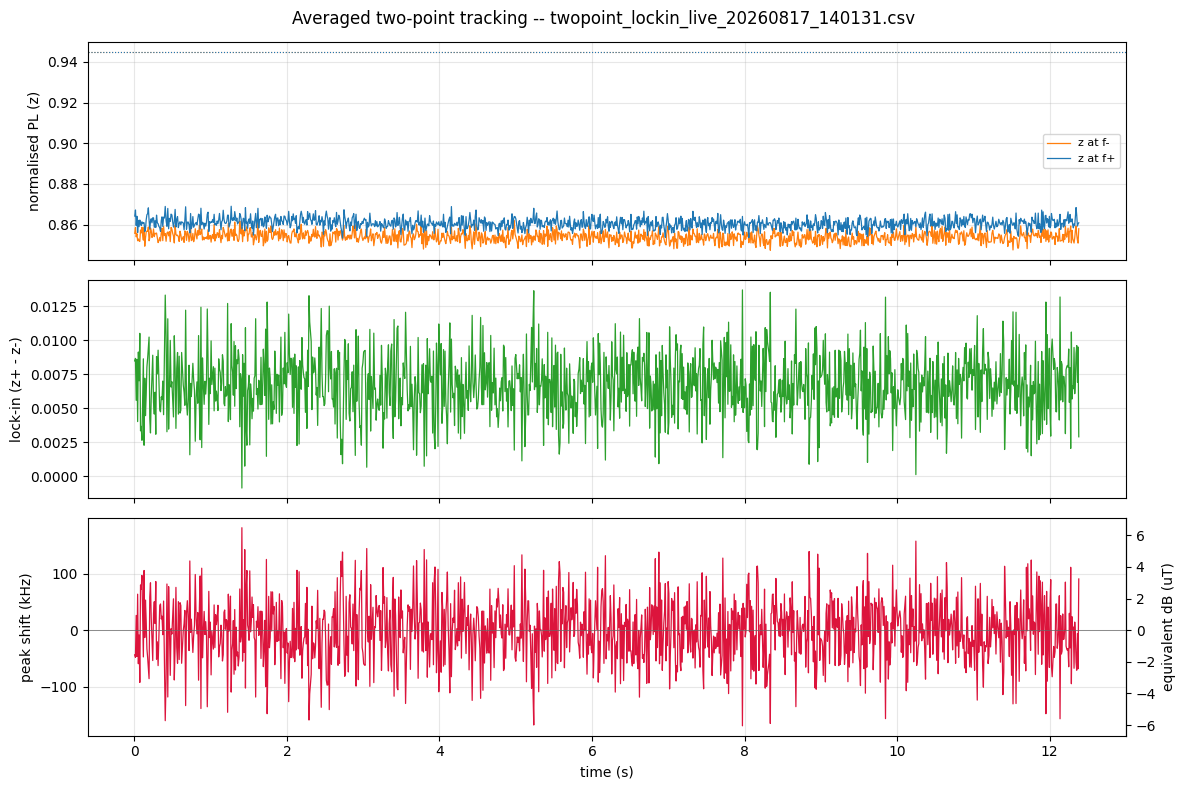

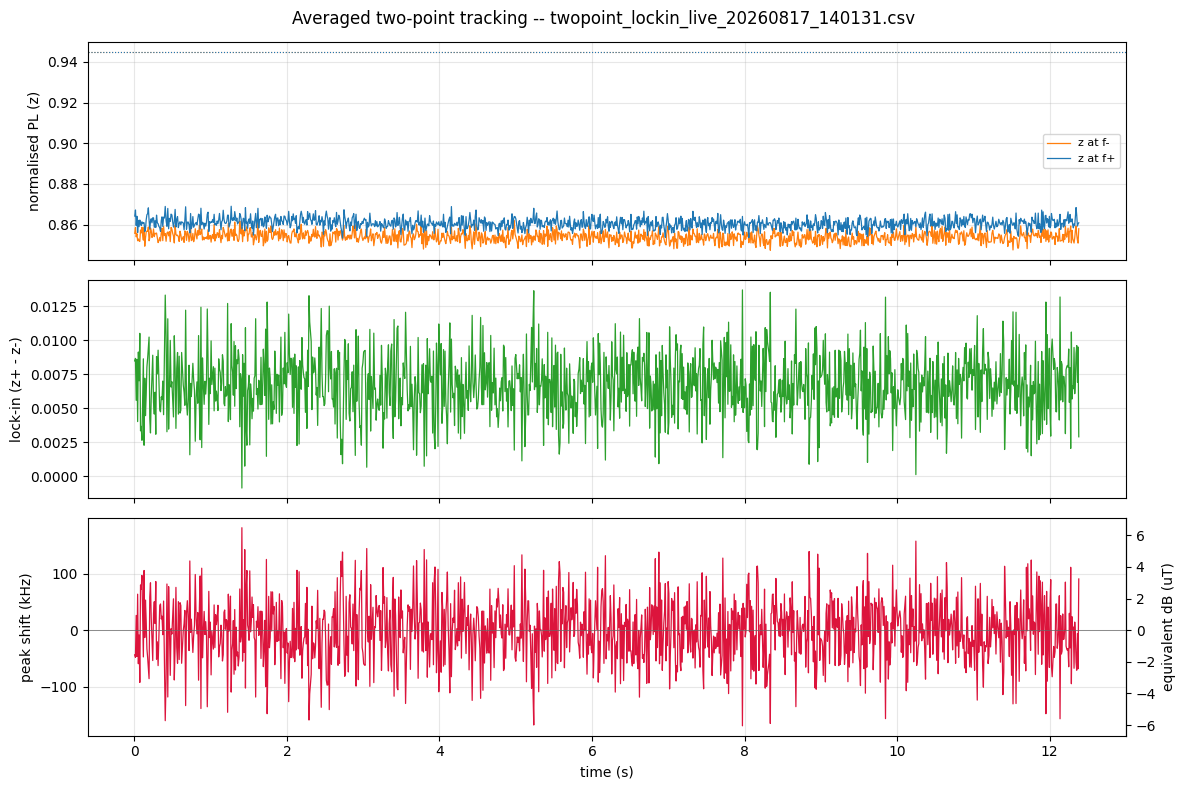

In [ ]:
# Step 4A - NORMAL (averaged) acquisition.  One sample per acquire() call, ~88 Hz.
#
# WHAT SETS THE RATE (measured 2026-08-04/06/14, three sessions):
#   An acquire() call costs ~10-11.4 ms of host round-trip WHATEVER the program does,
#   and the FPGA pulse work runs underneath it rather than adding to it:
#
#       FPGA readout   fastest call   median period
#         9.80 ms        10.2 ms        11.38 ms      (tau=213, 23 reps)
#         2.40 ms        10.1 ms        11.34 ms      (tau=120, 10 reps)
#
#   A 4x change in FPGA work moved the period by 0.04 ms. So:
#     * shortening tau does NOT raise this mode's rate. It never could.
#     * reps is FREE up to the call floor -- and under-filling it wastes photons,
#       because the call takes the same wall-clock time either way.
#   AVG_REPS_PER_BATCH = None uses reps_that_fit() to fill the budget automatically.
#
#   For anything above ~90 Hz use Step 4B (burst) or Step 4C (streaming); both pay the
#   host cost once per burst instead of once per sample.
#
# CAUTION at this rate: 60 Hz mains aliases to ~27 Hz, into the middle of the band, where
# it is indistinguishable from signal and cannot be filtered out. Step 5A says so; if you
# care about mains, run at >= 1 kHz.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b once first -- it defines TWOPOINT_CALIB and the "
                       "conversion helpers.")

import multipoint_lockin_program, twopoint_runner, spike_rejection
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
twopoint_runner = importlib.reload(twopoint_runner)
spike_rejection = importlib.reload(spike_rejection)
from multipoint_lockin_program import MultipointLockinODMR

# --- Pre-flight: make sure the board is not still busy with a previous cell. ---
# One RPC when everything is clean. If a cell was ever interrupted mid-acquire, the
# board can be left with a readout still running and a Pyro thread blocked on the
# streamer queue -- which a kernel restart does NOT clear. This detects that and
# resets the streamer, so this run does not inherit the previous one's packets.
# To do it by hand at any time:  MultipointLockinODMR.recover()
MultipointLockinODMR.ensure_idle()
from spike_rejection import HampelDespiker

# ----------------------------------------------------------------- parameters
AVG_REPS_PER_BATCH   = None      # None = fill the per-call floor for free (recommended)
AVG_DURATION_SEC     = 30        # None = run until the Interrupt button
AVG_PAIR_ORDER       = "forward" # "abba" cancels linear common-mode drift; costs 2x per rep
AVG_SKIP_REFERENCE   = TWOPOINT_SKIP_REFERENCE if "TWOPOINT_SKIP_REFERENCE" in globals() else True
AVG_RELAX_DELAY_TREG = 1000
AVG_OFF_RESONANCE_MHZ = TWOPOINT_OFF_RESONANCE_MHZ if "TWOPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0
AVG_AUTOZERO         = True      # re-zero (z+ - z-) on this run, not on the ODMR sweep
AVG_AUTOZERO_BATCHES = 20
AVG_SHOW_PLOT        = False     # False = headless; one static figure at the end
AVG_PLOT_REFRESH_EVERY = 10
AVG_CALIBRATE_FLOOR  = True      # measure the per-call floor before choosing reps
AVG_DESPIKE_ENABLED  = False     # raw-channel Hampel; see Step 5A for the better option
AVG_DESPIKE_WINDOW, AVG_DESPIKE_K_SIGMA, AVG_DESPIKE_WARMUP = 11, 4, 4
SAVE_EVERY_SEC = 5.0
# -----------------------------------------------------------------------------

# `_avg_`, not `_live_`: Step 4A and Step 4B both wrote `twopoint_lockin_live_*`,
# so an averaged run and a burst run were indistinguishable by filename.
AVG_CSV = TWOPOINT_DIR / f"twopoint_lockin_avg_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

cfg_avg = copy(default_config)
cfg_avg.multipoint_freqs_mhz      = list(TWOPOINT_FREQS_MHZ)
cfg_avg.odmr_reference_offres_mhz = AVG_OFF_RESONANCE_MHZ
cfg_avg.multipoint_skip_reference = bool(AVG_SKIP_REFERENCE)
cfg_avg.multipoint_pair_order     = str(AVG_PAIR_ORDER)
cfg_avg.multipoint_on_stale       = "warn"     # replays are not expected in averaged mode
cfg_avg.relax_delay_treg          = int(AVG_RELAX_DELAY_TREG)
cfg_avg.mw_start_fMHz = cfg_avg.mw_end_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg_avg.nsweep_points             = 1
cfg_avg.pre_init                  = False
cfg_avg.reps                      = int(AVG_REPS_PER_BATCH or 1)

# --- Choose reps against the floor this rig is actually showing today ---
_probe = MultipointLockinODMR(copy(cfg_avg))
_floor_s = None
if AVG_CALIBRATE_FLOOR:
    print("Measuring the per-call host floor (about 0.3 s)...")
    _cal = MultipointLockinODMR.measure_host_floor(_probe, n=20, reps=1)
    _floor_s = _cal["floor_s"]
    print(f"  fastest call {_cal['floor_s']*1e3:.2f} ms, median {_cal['median_s']*1e3:.2f} ms, "
          f"jitter {_cal['jitter_s']*1e3:.2f} ms (FPGA work in the probe: "
          f"{_cal['fpga_s']*1e3:.2f} ms)")
    if _cal["floor_s"] > 1.5 * MultipointLockinODMR.HOST_FLOOR_S:
        print("  NOTE: this rig is slower than the recorded default. The rate predictions "
              "below use the measurement, not the default.")

cfg_avg.reps = int(AVG_REPS_PER_BATCH or _probe.reps_that_fit(_floor_s))
prog_avg = MultipointLockinODMR(cfg_avg)
print()
print(prog_avg.describe_timing(host_call_s=None if _floor_s is None else _floor_s * 1.13,
                               host_floor_s=_floor_s))
print(f"Reference readout: {'SKIPPED' if AVG_SKIP_REFERENCE else 'taken'}   "
      f"reps/batch: {cfg_avg.reps}"
      + ("  (auto: filled the floor)" if AVG_REPS_PER_BATCH is None else "  (set by hand)"))

assert cfg_avg.pre_init is False, (
    "Averaged mode requires pre_init=False. An MW polarisation pulse before the body loop "
    "perturbs spins at every batch boundary and produces a transient.")

# --- Prime once with pre_init=True, discard the result ---
_cfg_prime = copy(cfg_avg); _cfg_prime.pre_init = True
_prog_prime = MultipointLockinODMR(_cfg_prime)
print("\nPriming spin polarization...")
_ = _prog_prime.acquire(progress=False)
del _prog_prime, _cfg_prime

# --- Auto-zero: measure this run's own (z+ - z-) zero ---
_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"])
_zero_lockin = None
if AVG_AUTOZERO:
    _z0 = []
    for _ in range(int(AVG_AUTOZERO_BATCHES)):
        _d0 = prog_avg.acquire(progress=False)
        _r0 = _d0.reference if _d0.reference is not None else [None, None]
        _z0.append(float(twopoint_z_from_counts(_d0.signal[1], _r0[1])
                         - twopoint_z_from_counts(_d0.signal[0], _r0[0])))
    _zero_lockin = float(np.median(_z0))
    _calib_zero = float(TWOPOINT_CALIB["baseline_plus"]) - float(TWOPOINT_CALIB["baseline_minus"])
    _denom = float(TWOPOINT_CALIB["slope_minus_per_mhz"]) - float(TWOPOINT_CALIB["slope_plus_per_mhz"])
    print(f"Auto-zero over {AVG_AUTOZERO_BATCHES} batches: removed a constant "
          f"{(_zero_lockin - _calib_zero) / _denom * 1e3:+.0f} kHz offset. Shifts are "
          f"measured from the start of this run, not from the ODMR sweep.")

_despiker = HampelDespiker(n_channels=2, window=AVG_DESPIKE_WINDOW,
                           k_sigma=AVG_DESPIKE_K_SIGMA, min_warmup=AVG_DESPIKE_WARMUP)

# --- Live loop ---
prog_avg.reset_freshness_counters()
_writer = twopoint_runner.IncrementalCsvWriter(AVG_CSV)
rows, _acq_hist, _n_watchdog = [], [], 0
_predicted_ms = prog_avg.total_time() * 1e3
_t0 = perf_counter(); _last_save = _t0; batch = 0
print(f"\nAcquiring into {AVG_CSV.name} ...")

try:
    while True:
        _t_start = perf_counter() - _t0
        d = prog_avg.acquire(progress=False)
        _t_end = perf_counter() - _t0
        _acq_dt = _t_end - _t_start
        _acq_hist.append(_acq_dt)
        if _acq_dt * 1e3 > 3.0 * max(_predicted_ms, 12.0) and _n_watchdog < 5:
            print(f"  WARNING batch {batch}: {_acq_dt*1e3:.0f} ms (host/network jitter)")
            _n_watchdog += 1

        _sig = np.atleast_2d(np.asarray(d.signal, dtype=float))
        _ref = np.atleast_2d(np.asarray(d.reference, dtype=float)) if d.reference is not None else None
        if AVG_DESPIKE_ENABLED:
            _clean, _flag = _despiker.update(_sig[0])
            _sig_c, _spike = _clean[None, :], _flag[None, :]
        else:
            _sig_c, _spike = _sig, np.zeros(_sig.shape, dtype=bool)

        _zm = np.asarray(twopoint_z_from_counts(_sig_c[:, 0], None if _ref is None else _ref[:, 0]), float)
        _zp = np.asarray(twopoint_z_from_counts(_sig_c[:, 1], None if _ref is None else _ref[:, 1]), float)
        _df = np.asarray(twopoint_delta_f_linear(_zm, _zp, zero_lockin=_zero_lockin), float)

        rows.extend(twopoint_runner.build_rows(
            batch, np.array([0.5 * (_t_start + _t_end)]), _acq_dt, _wallclock(),
            _sig_c, _ref, _sig, _ref, _spike, np.zeros_like(_spike),
            d.frequencies_mhz, _zm, _zp, _df,
            float(TWOPOINT_CALIB["f0_mhz"]), _gamma_nv))

        if perf_counter() - _last_save > SAVE_EVERY_SEC:
            _writer.flush(rows); _last_save = perf_counter()
        batch += 1
        if AVG_DURATION_SEC is not None and _t_end >= AVG_DURATION_SEC:
            break
except KeyboardInterrupt:
    print(f"Stopped by user after {batch} batches.")

_writer.flush(rows)
df_avg = pd.DataFrame(rows)
AVG_LAST_CSV = AVG_CSV

_dur = float(df_avg["time_s"].iloc[-1])
print(f"\nAveraged run finished: {len(df_avg)} samples in {_dur:.1f} s "
      f"-> {len(df_avg)/_dur:.1f} Hz")
twopoint_runner.report_timing(_acq_hist, prog_avg, cfg_avg.reps, _n_watchdog)
twopoint_runner.report_freshness(prog_avg, batch, "averaged")
twopoint_runner.report_calibration_validity(df_avg, TWOPOINT_CALIB)
twopoint_runner.report_shift(df_avg, _gamma_nv, _dur / len(df_avg))
print(f"\nSaved to: {AVG_CSV}")
display(FileLink(str(AVG_CSV)))
twopoint_runner.plot_run(df_avg, _gamma_nv,
                         f"Averaged two-point tracking -- {AVG_CSV.name}", TWOPOINT_CALIB)

### Step 5A — Analysis: averaged run

Thin wrapper over `twopoint_postprocess.process_averaged`. Reports the per-call floor and
how much of it the FPGA actually used, the spectrum, the sensitivity, and the mains-alias
warning that this rate makes unavoidable.

Despiking defaults to `"shift"` — the **differential**. Filtering the two parked channels
independently is worse than doing nothing: they are 0.84–0.97 correlated through the common
PL, so a one-sided replacement injects differential noise. Measured on 08-14: per-channel
despiking raised σ from 54.6 to 55.8 kHz, differential lowered it to 53.6 kHz.

AVERAGED run -- twopoint_lockin_live_20260817_135828.csv
--------------------------------------------------------
  n_samples               : 1340
  duration_s              : 13.12
  rate_hz                 : 102.1
  acq_p05_ms              : 8.825
  acq_median_ms           : 9.539
  acq_p95_ms              : 10.95
  acq_outliers_gt3x       : 2
  readout_quantum_D       : 1290240
  fpga_readout_ms         : 8.4
  fpga_share_of_period    : 0.8574
  stale_batches           : 0
  despiked_samples        : 194

  sample rate        : 102.1 Hz
  sigma(peak shift)  : 190.2 kHz (6786.11 nT)
  eta = sigma*sqrt(2dt): 949.9 nT/sqrt(Hz)
  measured ASD floor : 756.4 nT/sqrt(Hz) (10-41 Hz)
  ALIAS WARNING      : 60 Hz aliases to 42.1 Hz and cannot be separated from signal there
  ALIAS WARNING      : 120 Hz aliases to 17.9 Hz and cannot be separated from signal there
  ALIAS WARNING      : 180 Hz aliases to 24.1 Hz and cannot be separated from signal there

  NOTE: per-call host floor <= 8.83 ms (f

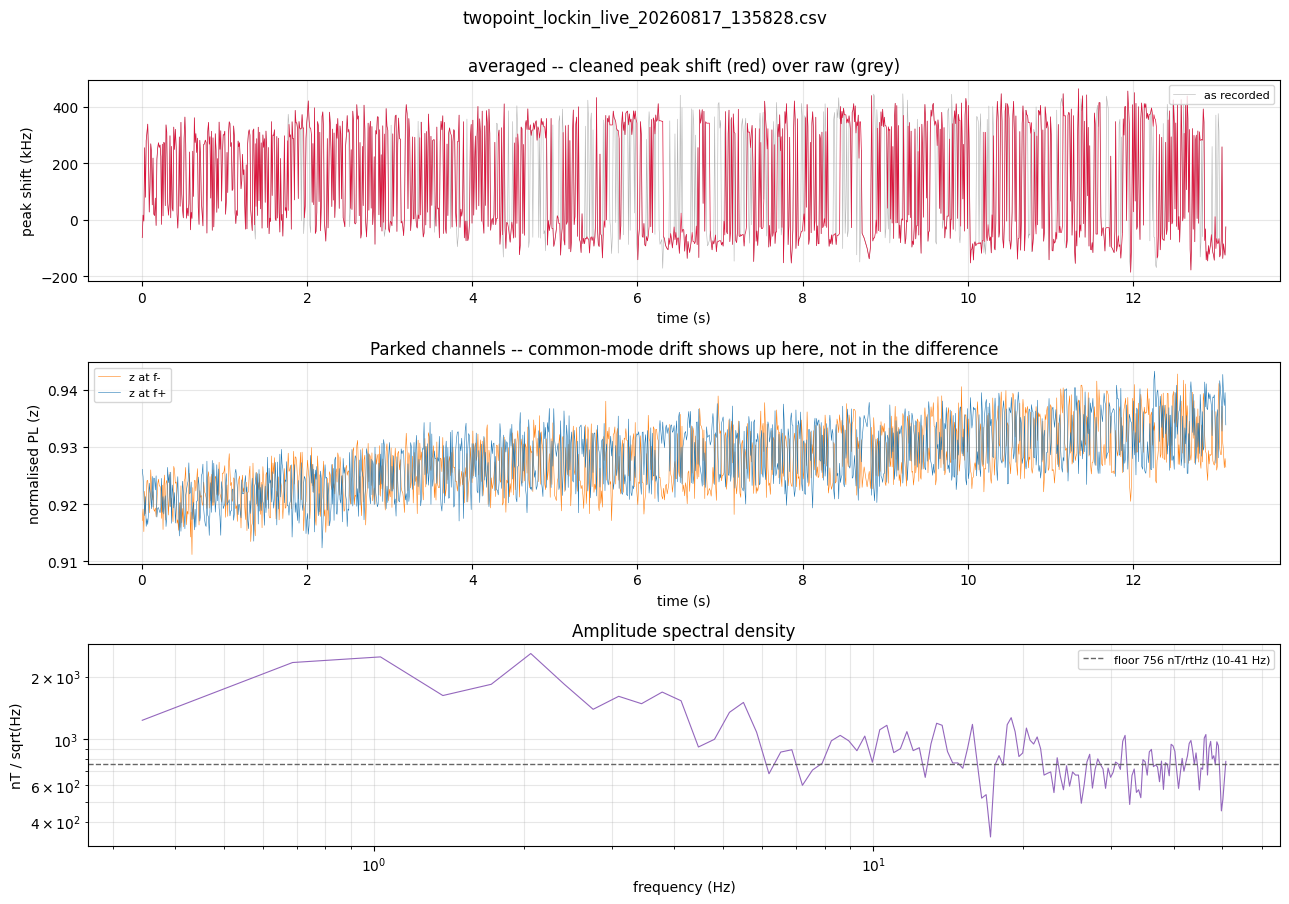

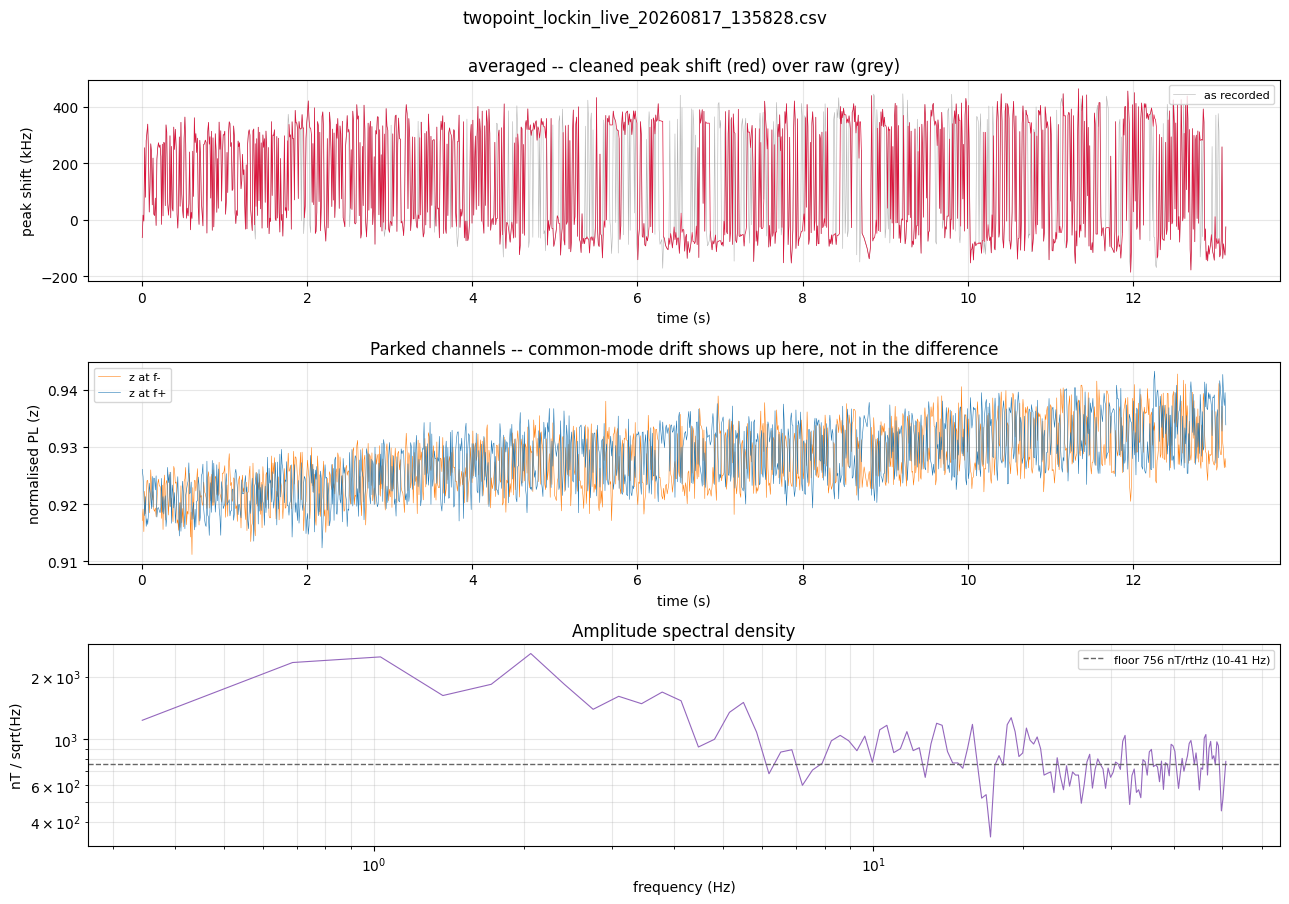

In [28]:
# Step 5A - Analysis of the averaged run: clean, spectrum, sensitivity.
# All of the work is in notebook_modules/twopoint_postprocess.py and twopoint_spectra.py.
import importlib
import twopoint_postprocess, twopoint_spectra
twopoint_postprocess = importlib.reload(twopoint_postprocess)
twopoint_spectra = importlib.reload(twopoint_spectra)

A5_CSV = AVG_LAST_CSV if "AVG_LAST_CSV" in globals() else None   # or a Path to an older run
A5_DESPIKE = "shift"     # "shift" (differential, recommended) | "channels" | False
A5_DETREND = False       # True removes slow drift before the statistics
A5_NOTCH_MAINS = False   # diagnostic only at this rate: 60 Hz is ALIASED here

res_avg = twopoint_postprocess.process(A5_CSV, mode="averaged", despike=A5_DESPIKE,
                                       detrend=A5_DETREND, notch_mains=A5_NOTCH_MAINS)
print(res_avg.describe())
res_avg.figure(show=True)

## Step 4B — Burst mode  ·  4167 Hz inside a burst, ~74% duty cycle

One `acquire()` keeps the rep axis, so a single call returns `BURST_REPS` time samples
spaced by the FPGA cadence (240 µs at τ = 120 µs). The ~10 ms host cost is paid once per
burst instead of once per sample, which is what buys the rate.

### Open defect: about half of all bursts are replays

The accumulated buffer is read before the new run has refilled it, so the call returns the
*previous* burst's contents. Measured **50.0% (185 of 371 batches)** on 2026-08-14 and
50–52% on 2026-08-06, always strictly alternating (~12 ms / ~120 ms).

`reset_tproc=True` — the 2026-08-12 fix — **does not work.** The 08-14 run used it and the
replay fraction was unchanged. The root cause is still unknown.

What this cell does about it: `multipoint_on_stale = "drop"` makes the freshness guard
re-acquire and, failing that, skip the batch. A replayed burst is therefore *not written to
the CSV*, so the recorded rate is honest — you lose duty cycle, not correctness. Before
this, half of every burst file was duplicates and the quoted 4.4 kHz was really 2.1 kHz.

Two smaller things also handled here:

* **Row 0 of every real batch runs ~1.4% high** (+17 ADC on 08-14) — a genuine post-idle
  transient, separate from the replay. `BURST_DROP_FIRST_REP` removes it.
* **Timestamps come from the FPGA cadence**, not from the measured acquire window. The old
  cell spread each burst across its own wall-clock duration, which compressed the time axis
  by ~10× on the short (stale) batches and produced the striping in the plots.

If you want sustained high rate without any of this, use **Step 4C** — streaming re-arms
nothing mid-run, so the race cannot occur.

In [46]:
# Step 4B - BURST acquisition.  One acquire() returns `reps` samples at the full FPGA
# cadence, so the ~10 ms host cost is paid once per BURST instead of once per sample.
# At tau = 120 us that is 4167 Hz inside a burst.
#
# KNOWN DEFECT, STILL OPEN. Roughly half of all burst acquires come back as a
# bit-identical replay of the previous one -- the accumulated buffer is read before the
# new run has refilled it. Measured 50.0% (185/371 batches) on 2026-08-14 and 50-52% on
# 2026-08-06. Forcing the tProc stop (reset_tproc=True) does NOT fix it: that was the
# 2026-08-12 change and the 08-14 run used it.
#
# What we do about it here: cfg.multipoint_on_stale = "drop" makes the freshness guard
# re-acquire and, failing that, return None, so a replayed batch is SKIPPED instead of
# being written to the CSV as if it were data. The cost is duty cycle, not correctness --
# the recorded rate becomes honest. Check BURST_STALE_FRACTION at the end.
#
# If you want sustained high rate without this, use Step 4C (streaming): it re-arms
# nothing mid-run and cannot hit the race at all.
from copy import copy
from time import perf_counter, time as _wallclock
from datetime import datetime
import importlib
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b once first.")

import multipoint_lockin_program, twopoint_runner
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
twopoint_runner = importlib.reload(twopoint_runner)
from multipoint_lockin_program import MultipointLockinODMR

# --- Pre-flight: make sure the board is not still busy with a previous cell. ---
# One RPC when everything is clean. If a cell was ever interrupted mid-acquire, the
# board can be left with a readout still running and a Pyro thread blocked on the
# streamer queue -- which a kernel restart does NOT clear. This detects that and
# resets the streamer, so this run does not inherit the previous one's packets.
# To do it by hand at any time:  MultipointLockinODMR.recover()
MultipointLockinODMR.ensure_idle()

# ----------------------------------------------------------------- parameters
BURST_REPS            = 500      # reps (= time samples) returned by one acquire()
BURST_DURATION_SEC    = 30
BURST_PAIR_ORDER      = "forward"
BURST_SKIP_REFERENCE  = TWOPOINT_SKIP_REFERENCE if "TWOPOINT_SKIP_REFERENCE" in globals() else True
BURST_RELAX_DELAY_TREG = 1000
BURST_OFF_RESONANCE_MHZ = TWOPOINT_OFF_RESONANCE_MHZ if "TWOPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0
BURST_ON_STALE        = "drop"   # "drop" | "warn" | "raise". Keep "drop".
BURST_STALE_RETRIES   = 2
BURST_RESET_TPROC     = True     # kept available; measured NOT to fix the replay
BURST_DROP_FIRST_REP  = True     # row 0 of every batch runs +1.4% high (a real transient)
BURST_AUTOZERO_REPS   = 2000
SAVE_EVERY_SEC = 5.0
# -----------------------------------------------------------------------------

# `_burst_`, not `_live_`: Step 4A used to write the same name, which is why runs
# were hard to tell apart in data/twopoint_lockin/.
BURST_CSV = TWOPOINT_DIR / f"twopoint_lockin_burst_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

cfg_burst = copy(default_config)
cfg_burst.multipoint_freqs_mhz      = list(TWOPOINT_FREQS_MHZ)
cfg_burst.odmr_reference_offres_mhz = BURST_OFF_RESONANCE_MHZ
cfg_burst.multipoint_skip_reference = bool(BURST_SKIP_REFERENCE)
cfg_burst.multipoint_pair_order     = str(BURST_PAIR_ORDER)
cfg_burst.multipoint_on_stale       = str(BURST_ON_STALE)
cfg_burst.multipoint_stale_retries  = int(BURST_STALE_RETRIES)
cfg_burst.relax_delay_treg          = int(BURST_RELAX_DELAY_TREG)
cfg_burst.mw_start_fMHz = cfg_burst.mw_end_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg_burst.nsweep_points             = 1
cfg_burst.pre_init                  = False
cfg_burst.reps                      = int(BURST_REPS)

prog_burst = MultipointLockinODMR(cfg_burst)
_cadence = prog_burst.time_per_rep()
print(prog_burst.describe_timing())
print(f"Burst: {BURST_REPS} reps x {_cadence*1e6:.0f} us = {BURST_REPS*_cadence*1e3:.1f} ms "
      f"of FPGA work per acquire -> {1/_cadence:.0f} Hz inside a burst")
print(f"Stale policy: {BURST_ON_STALE} (retries={BURST_STALE_RETRIES}), "
      f"reset_tproc={BURST_RESET_TPROC}")

# --- Prime, then auto-zero on a dedicated averaged acquire ---
_cfg_prime = copy(cfg_burst); _cfg_prime.pre_init = True; _cfg_prime.reps = 100
_p = MultipointLockinODMR(_cfg_prime); _ = _p.acquire(progress=False); del _p, _cfg_prime
print("\nPriming done.")

_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"])
_cfg_zero = copy(cfg_burst); _cfg_zero.reps = int(BURST_AUTOZERO_REPS)
_cfg_zero.multipoint_on_stale = "warn"
_pz = MultipointLockinODMR(_cfg_zero)
_d0 = _pz.acquire(progress=False)
_r0 = _d0.reference if _d0.reference is not None else [None, None]
_zero_lockin = float(twopoint_z_from_counts(_d0.signal[1], _r0[1])
                     - twopoint_z_from_counts(_d0.signal[0], _r0[0]))
_calib_zero = float(TWOPOINT_CALIB["baseline_plus"]) - float(TWOPOINT_CALIB["baseline_minus"])
_denom = float(TWOPOINT_CALIB["slope_minus_per_mhz"]) - float(TWOPOINT_CALIB["slope_plus_per_mhz"])
print(f"Auto-zero over {BURST_AUTOZERO_REPS} reps: removed a constant "
      f"{(_zero_lockin - _calib_zero) / _denom * 1e3:+.0f} kHz offset.")
del _pz, _cfg_zero, _d0, _r0

# --- Burst loop ---
prog_burst.reset_freshness_counters()
_writer = twopoint_runner.IncrementalCsvWriter(BURST_CSV)
rows, _acq_hist = [], []
_n_skipped = 0
_t0 = perf_counter(); _last_save = _t0; batch = 0
print(f"\nAcquiring into {BURST_CSV.name} ...")

try:
    while True:
        _t_start = perf_counter() - _t0
        d = prog_burst.acquire(progress=False, per_rep=True, reset_tproc=BURST_RESET_TPROC)
        _t_end = perf_counter() - _t0
        if d is None:
            # Every retry came back stale. Skipping is the honest thing to do: writing
            # the buffer would put a replay of the previous burst into the CSV.
            _n_skipped += 1
            if BURST_DURATION_SEC is not None and _t_end >= BURST_DURATION_SEC:
                break
            continue
        _acq_dt = _t_end - _t_start
        _acq_hist.append(_acq_dt)

        _sig = np.atleast_2d(np.asarray(d.signal, dtype=float))
        _ref = np.atleast_2d(np.asarray(d.reference, dtype=float)) if d.reference is not None else None
        _n = _sig.shape[0]

        # Timestamps come from the FPGA cadence, never from the measured acquire window.
        # The old cell spread each burst across its own wall-clock duration, which for a
        # stale 12 ms batch and a real 120 ms batch meant a 10x alternating compression of
        # the time axis. The cadence is constant and exactly known.
        _t_samp = _t_start + np.arange(_n) * _cadence
        _first = 1 if (BURST_DROP_FIRST_REP and _n > 1) else 0

        _zm = np.asarray(twopoint_z_from_counts(_sig[:, 0], None if _ref is None else _ref[:, 0]), float)
        _zp = np.asarray(twopoint_z_from_counts(_sig[:, 1], None if _ref is None else _ref[:, 1]), float)
        _df = np.asarray(twopoint_delta_f_linear(_zm, _zp, zero_lockin=_zero_lockin), float)
        _spike = np.zeros(_sig.shape, dtype=bool)

        rows.extend(twopoint_runner.build_rows(
            batch, _t_samp[_first:], _acq_dt, _wallclock(),
            _sig[_first:], None if _ref is None else _ref[_first:],
            _sig[_first:], None if _ref is None else _ref[_first:],
            _spike[_first:], _spike[_first:],
            d.frequencies_mhz, _zm[_first:], _zp[_first:], _df[_first:],
            float(TWOPOINT_CALIB["f0_mhz"]), _gamma_nv))

        if perf_counter() - _last_save > SAVE_EVERY_SEC:
            _writer.flush(rows); _last_save = perf_counter()
        batch += 1
        if BURST_DURATION_SEC is not None and _t_end >= BURST_DURATION_SEC:
            break
except KeyboardInterrupt:
    print(f"Stopped by user after {batch} bursts.")

_writer.flush(rows)
df_burst = pd.DataFrame(rows)
BURST_LAST_CSV = BURST_CSV

_dur = float(df_burst["time_s"].iloc[-1])
_attempts = batch + _n_skipped
BURST_STALE_FRACTION = _n_skipped / _attempts if _attempts else 0.0
print(f"\nBurst run finished: {len(df_burst)} samples from {batch} bursts in {_dur:.1f} s")
print(f"  within-burst rate : {1/_cadence:.0f} Hz ({_cadence*1e6:.0f} us cadence)")
print(f"  effective rate    : {len(df_burst)/_dur:.0f} Hz (includes the gaps between bursts)")
print(f"  duty cycle        : {100*batch*BURST_REPS*_cadence/_dur:.0f}%")
print(f"  stale bursts      : {_n_skipped}/{_attempts} = {100*BURST_STALE_FRACTION:.1f}% "
      f"{'DISCARDED, not recorded' if BURST_ON_STALE == 'drop' else 'RECORDED AS DATA'}")
if BURST_ON_STALE == "drop" and BURST_STALE_FRACTION > 0.05:
    print("  -> the race is still open. The numbers above are honest, but half the "
          "wall-clock time is being thrown away. Prefer Step 4C (streaming).")
twopoint_runner.report_timing(_acq_hist, prog_burst, cfg_burst.reps)
twopoint_runner.report_freshness(prog_burst, batch, "burst")
twopoint_runner.report_calibration_validity(df_burst, TWOPOINT_CALIB)
twopoint_runner.report_shift(df_burst, _gamma_nv, _cadence)
print(f"\nSaved to: {BURST_CSV}")
display(FileLink(str(BURST_CSV)))
twopoint_runner.plot_run(df_burst, _gamma_nv,
                         f"Burst two-point tracking -- {BURST_CSV.name}", TWOPOINT_CALIB)

2 freqs, order=forward (2 slots/rep), tau=120.0 us, 500 reps -> 240 us/rep, 120.00 ms FPGA work
  averaged mode: FPGA work exceeds the 10.1 ms floor, so reps now trades against rate one for one -> 8.3 Hz
  burst/stream : 4167 Hz per rep (240 us cadence); the floor is paid once per burst instead of once per sample
Burst: 500 reps x 240 us = 120.0 ms of FPGA work per acquire -> 4167 Hz inside a burst
Stale policy: drop (retries=2), reset_tproc=True

Priming done.


KeyboardInterrupt: 

### Step 5B — Analysis: burst run

Repairs what Step 4B could not prevent, and works on files recorded before the `"drop"`
policy existed: removes replayed batches and row-0 transients, rebuilds the time axis on
the **exact** cadence recovered from the ADC value quantisation (240.0 µs at τ = 120 µs,
against the 269 µs a wall-clock estimate gives — a 12% error that would stretch the rate
and the whole frequency axis), and computes the spectrum per burst segment so the dead time
between bursts is never transformed across.

The command-line equivalent, for a file you are not holding in the notebook:

```
python scripts/clean_burst_lockin.py <live_csv> --outdir analysis/
```

In [47]:
# Step 5B - Analysis of the burst run.
# Drops replayed batches and row-0 transients, rebuilds the time axis on the exact FPGA
# cadence (recovered from the value quantisation, not from wall-clock), and computes the
# spectrum per burst segment so the dead time between bursts is never transformed across.
import importlib
import twopoint_postprocess, twopoint_spectra
twopoint_postprocess = importlib.reload(twopoint_postprocess)
twopoint_spectra = importlib.reload(twopoint_spectra)

B5_CSV = BURST_LAST_CSV if "BURST_LAST_CSV" in globals() else None
B5_DROP_STALE = True         # drop batches that replay the previous one
B5_DROP_FIRST_SAMPLE = True  # drop row 0 of every batch (the +1.4% transient)
B5_DESPIKE = "shift"
B5_NOTCH_MAINS = False       # per segment; a 120 ms burst only gives ~8 Hz bins

res_burst = twopoint_postprocess.process(
    B5_CSV, mode="burst", drop_stale=B5_DROP_STALE,
    drop_first_sample=B5_DROP_FIRST_SAMPLE, despike=B5_DESPIKE,
    notch_mains=B5_NOTCH_MAINS)
print(res_burst.describe())
res_burst.figure(show=True)

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

## Step 4C — Streaming mode  ·  the 1 kHz path

One `config_all`, one `start_readout`, then nothing but draining the streamer queue. No
per-batch reconfiguration, therefore no replay race, no duty-cycle hole, and timestamps
that follow the FPGA cadence exactly.

**It works, and the rate claim held up.** The 2026-08-14 run
(`twopoint_lockin_stream_20260814_145442.csv`) delivered **1041.7 Hz** — 31,250 samples in
30.000 s, `rep_index` advancing by exactly 4 with **zero gaps and zero duplicate rows**
across 125,000 reps. `STREAM_TARGET_HZ = None` keeps every rep instead, for the full
4167 Hz.

### Open defect: the noise floor is ~4× the burst floor

At the same τ, ten minutes apart, with nothing changed on the bench, the streamed data
measured **5.3–6.3× the burst amplitude spectral density, flat across 10–500 Hz**:

| band | stream | burst (cleaned) | ratio |
|---|---|---|---|
| 10–30 Hz | 235 nT/√Hz | 38.6 | 6.08 |
| 100–200 Hz | 231 | 38.8 | 5.97 |
| 350–500 Hz | 250 | 39.7 | 6.30 |

Ruled out: mains (4.5% of the variance), drift, packet boundaries, packet size, torn reads.
A flat multiplicative excess with no structure is what a *readout-path* difference looks
like, not a physical one. The configuration sequence has been aligned with `acquire()`'s
(a missing `reload_mem()`), which is the cheapest candidate — but this is **not confirmed**.
Settle it with the interleaved A/B:

```
python scripts/profile_twopoint_acquire.py --compare-read-paths
```

### Also expect a PL droop

With no gap between acquires the sample heats: the 08-14 run fell **25%** in PL over 30 s.
It is mostly common-mode and largely cancels in `z+ − z−`, but it walks the operating point
off the calibrated flank. Step 5C detrends it and reports the size.

In [48]:
# Step 4C - STREAMING acquisition.
#
# Prefer this over Step 4's burst mode for anything above a few hundred Hz: one FPGA run,
# no per-batch reconfiguration, no duty-cycle hole, and no stale-buffer race by construction.
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b once before streaming -- it defines TWOPOINT_CALIB and "
                       "the conversion helpers.")

import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

# --- Pre-flight: make sure the board is not still busy with a previous cell. ---
# One RPC when everything is clean. If a cell was ever interrupted mid-acquire, the
# board can be left with a readout still running and a Pyro thread blocked on the
# streamer queue -- which a kernel restart does NOT clear. This detects that and
# resets the streamer, so this run does not inherit the previous one's packets.
# To do it by hand at any time:  MultipointLockinODMR.recover()
MultipointLockinODMR.ensure_idle()

# --- Streaming parameters ---
STREAM_DURATION_SEC   = 30.0
STREAM_TARGET_HZ      = 1000.0   # None = keep every rep (full cadence, ~4.2 kHz at tau=120)
STREAM_PAIR_ORDER     = "forward"  # "abba" cancels linear common-mode drift; costs 2x per rep
STREAM_SKIP_REFERENCE = TWOPOINT_SKIP_REFERENCE if "TWOPOINT_SKIP_REFERENCE" in globals() else True
STREAM_RELAX_TREG     = 1000
STREAM_AUTOZERO_REPS  = 2000     # reps in the dedicated zero measurement before the run
STREAM_SHOW_PROGRESS  = False

_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
STREAM_CSV = TWOPOINT_DIR / f"twopoint_lockin_stream_{_stamp}.csv"
STREAM_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the streaming program. cfg.reps IS the run length: the tProc loops that many
# times and ends, so it has to be set before compilation and cannot change mid-run. ---
cfg_stream = copy(default_config)
cfg_stream.multipoint_freqs_mhz      = list(TWOPOINT_FREQS_MHZ)
cfg_stream.odmr_reference_offres_mhz = (TWOPOINT_OFF_RESONANCE_MHZ
                                        if "TWOPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0)
cfg_stream.multipoint_skip_reference = bool(STREAM_SKIP_REFERENCE)
cfg_stream.multipoint_pair_order     = str(STREAM_PAIR_ORDER)
cfg_stream.relax_delay_treg          = int(STREAM_RELAX_TREG)
cfg_stream.mw_start_fMHz             = float(TWOPOINT_FREQS_MHZ[0])
cfg_stream.mw_end_fMHz               = float(TWOPOINT_FREQS_MHZ[0])
cfg_stream.nsweep_points             = 1
cfg_stream.pre_init                  = False

_probe = MultipointLockinODMR(copy(cfg_stream))
_cadence = _probe.time_per_rep()
_total_reps = max(1, int(round(STREAM_DURATION_SEC / _cadence)))
cfg_stream.reps = _total_reps

prog_stream = MultipointLockinODMR(cfg_stream)

# Host-side averaging factor. Whole reps only, so the achieved rate is the cadence divided
# by an integer rather than exactly the target.
_bin = 1 if STREAM_TARGET_HZ is None else max(1, int(round(1.0 / (STREAM_TARGET_HZ * _cadence))))
_achieved_hz = 1.0 / (_bin * _cadence)

print(prog_stream.describe_timing())
print(f"Raw cadence      : {_cadence * 1e6:.1f} us/rep -> {1 / _cadence:.0f} Hz")
print(f"Host averaging   : {_bin} rep(s)/sample -> {_achieved_hz:.1f} Hz"
      + ("" if STREAM_TARGET_HZ is None else f" (target {STREAM_TARGET_HZ:.0f} Hz)"))
print(f"Run length       : {_total_reps} reps = {_total_reps * _cadence:.1f} s")
try:
    _head = prog_stream.stream_headroom()
    print(f"Buffer headroom  : {_head['shots_that_fit']} shots "
          f"({_head['seconds_that_fit']:.2f} s) fit in the {_head['avg_maxlen']}-entry buffer; "
          f"board transfers every ~{_head['worker_stride_shots']} shots")
except Exception as _e:
    print(f"Buffer headroom  : could not read avg_maxlen ({_e})")

# --- Priming acquire with pre_init=True, results discarded (same as Step 4) ---
cfg_prime = copy(cfg_stream)
cfg_prime.pre_init = True
cfg_prime.reps = 100
_prog_prime = MultipointLockinODMR(cfg_prime)
print("\nPriming spin polarization...")
_ = _prog_prime.acquire(progress=False)
del _prog_prime, cfg_prime
print("Priming done.")

# --- Auto-zero BEFORE the stream, not during it ---
# Without a per-shot reference the zero of (z+ - z-) no longer matches the ODMR sweep's, so
# it has to be measured on this run. Doing it inside the stream would convert the first
# samples against the calibration zero and the rest against the measured one, leaving a step
# in the middle of one file. A dedicated averaged acquire at pre_init=False costs one
# STREAM_AUTOZERO_REPS-long run and makes the whole stream self-consistent.
cfg_zero = copy(cfg_stream)
cfg_zero.reps = int(STREAM_AUTOZERO_REPS)
_prog_zero = MultipointLockinODMR(cfg_zero)
_d0 = _prog_zero.acquire(progress=False)
_r0 = _d0.reference if _d0.reference is not None else [None, None]
_zero_lockin = float(twopoint_z_from_counts(_d0.signal[1], _r0[1])
                     - twopoint_z_from_counts(_d0.signal[0], _r0[0]))
_calib_zero = float(TWOPOINT_CALIB["baseline_plus"]) - float(TWOPOINT_CALIB["baseline_minus"])
_denom = float(TWOPOINT_CALIB["slope_minus_per_mhz"]) - float(TWOPOINT_CALIB["slope_plus_per_mhz"])
print(f"Auto-zero over {STREAM_AUTOZERO_REPS} reps: (z+ - z-) zero = {_zero_lockin:+.6e} "
      f"(sweep said {_calib_zero:+.6e})")
print(f"  -> removes a constant {(_zero_lockin - _calib_zero) / _denom * 1e3:+.0f} kHz offset. "
      f"Shifts are measured from the start of this run, not from the ODMR sweep.")
del _prog_zero, cfg_zero, _d0, _r0
print("\nStreaming.\n")

# --- Stream, converting and writing incrementally ---
_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"])
_pending = []          # reps not yet forming a whole averaging bin
_rows = []
_csv_written = 0
_n_packets = 0
_t_wall_start = perf_counter()


def _flush_stream_csv():
    """Append rows recorded since the last flush; header written only once."""
    global _csv_written
    if len(_rows) == _csv_written:
        return
    pd.DataFrame(_rows[_csv_written:]).to_csv(
        STREAM_CSV, mode="w" if _csv_written == 0 else "a",
        header=(_csv_written == 0), index=False)
    _csv_written = len(_rows)


_last_save = perf_counter()
try:
    for _pkt in prog_stream.stream(total_reps=_total_reps, progress=STREAM_SHOW_PROGRESS):
        _n_packets += 1
        _sig = np.atleast_2d(np.asarray(_pkt.signal, dtype=float))
        _ref = (np.atleast_2d(np.asarray(_pkt.reference, dtype=float))
                if _pkt.reference is not None else None)

        # Bin whole reps. Leftovers carry into the next packet so no rep is dropped and
        # bins never straddle a gap -- there are no gaps in a stream.
        _start_rep = _pkt.first_rep
        if _pending:
            _sig = np.concatenate([_pending[0], _sig], axis=0)
            _ref = (np.concatenate([_pending[1], _ref], axis=0)
                    if _ref is not None and _pending[1] is not None else _ref)
            _start_rep -= _pending[0].shape[0]
            _pending = []

        _n_full = (_sig.shape[0] // _bin) * _bin
        if _n_full < _sig.shape[0]:
            _pending = [_sig[_n_full:], None if _ref is None else _ref[_n_full:]]
        if _n_full == 0:
            continue

        _sig_b = _sig[:_n_full].reshape(-1, _bin, _sig.shape[1]).mean(axis=1)
        _ref_b = (None if _ref is None
                  else _ref[:_n_full].reshape(-1, _bin, _ref.shape[1]).mean(axis=1))

        _zm = np.asarray(twopoint_z_from_counts(
            _sig_b[:, 0], None if _ref_b is None else _ref_b[:, 0]), dtype=float)
        _zp = np.asarray(twopoint_z_from_counts(
            _sig_b[:, 1], None if _ref_b is None else _ref_b[:, 1]), dtype=float)

        _df = np.asarray(twopoint_delta_f_linear(_zm, _zp, zero_lockin=_zero_lockin),
                         dtype=float)
        # Timestamps from the FPGA cadence, never from arrival time.
        _t = (_start_rep + (np.arange(_sig_b.shape[0]) + 0.5) * _bin) * _cadence
        _now = _wallclock()

        for _k in range(_sig_b.shape[0]):
            _rows.append({
                "packet": _n_packets,
                "rep_index": int(_start_rep + _k * _bin),
                "reps_averaged": _bin,
                "time_s": float(_t[_k]),
                "timestamp_epoch_s": _now,
                "peak_01": float(_sig_b[_k, 0]),
                "peak_01_freq_mhz": float(_pkt.frequencies_mhz[0]),
                "peak_02": float(_sig_b[_k, 1]),
                "peak_02_freq_mhz": float(_pkt.frequencies_mhz[1]),
                "z_minus": float(_zm[_k]),
                "z_plus": float(_zp[_k]),
                "lockin_signal": float(_zp[_k] - _zm[_k]),
                "delta_f_mhz": float(_df[_k]),
                "peak_shift_kHz": float(_df[_k]) * 1e3,
                "f_new_mhz": float(TWOPOINT_CALIB["f0_mhz"]) + float(_df[_k]),
                "B_shift_uT": float(_df[_k]) / _gamma_nv,
            })

        if perf_counter() - _last_save > 5.0:
            _flush_stream_csv()
            _last_save = perf_counter()
except KeyboardInterrupt:
    print(f"Stream stopped by user after {len(_rows)} samples.")
finally:
    _flush_stream_csv()

_wall = perf_counter() - _t_wall_start
df_stream = pd.DataFrame(_rows)

# --- Summary ---
print(f"\nStream finished: {len(df_stream)} samples from {_n_packets} packets "
      f"in {_wall:.1f} s wall clock")
if len(df_stream):
    _span = float(df_stream["time_s"].iloc[-1] - df_stream["time_s"].iloc[0])
    _reps_seen = int(df_stream["rep_index"].iloc[-1] + _bin)
    print(f"  FPGA time covered   : {_reps_seen * _cadence:.2f} s over {_reps_seen} reps")
    print(f"  duty cycle          : {100 * _reps_seen * _cadence / _wall:.1f}% "
          f"(streaming has no inter-burst gap; the remainder is setup)")
    print(f"  sample rate         : {len(df_stream) / _span:.1f} Hz "
          f"(target {STREAM_TARGET_HZ})")
    _dt = np.diff(df_stream["time_s"].to_numpy())
    print(f"  timestamp spacing   : {_dt.min() * 1e6:.1f} - {_dt.max() * 1e6:.1f} us "
          f"(uniform by construction; jitter here means dropped reps)")
    _sh = df_stream["peak_shift_kHz"].to_numpy(float)
    _sh = _sh[np.isfinite(_sh)]
    if _sh.size:
        print(f"  peak shift          : mean {_sh.mean():+.1f} kHz, std {_sh.std():.1f} kHz")
        print(f"  equivalent field    : std {_sh.std() * 1e-3 / _gamma_nv:.3f} uT, "
              f"eta ~ {_sh.std() / _gamma_nv * np.sqrt(_bin * _cadence):.0f} nT/rtHz")
# --- QC: prove the rep axis is exact rather than assuming it ---
_qc = prog_stream.stream_qc()
if _qc:
    print(f"\nStream QC: {_qc['packets']} packets, "
          f"{_qc['packet_reps_min']:.0f}-{_qc['packet_reps_max']:.0f} reps each "
          f"(median {_qc['packet_reps_median']:.0f})")
    print(f"  reps collected     : {_qc['collected']}/{_qc['expected_reps']} "
          f"({_qc['reps_missing']} missing)")
    print(f"  duty cycle         : {100 * _qc['duty_cycle']:.1f}% "
          f"(streaming has no inter-burst gap; the remainder is setup)")
    if _qc["reps_missing"] or _qc["short_reads"]:
        print("  WARNING: reps were dropped -- the cadence timestamps are wrong "
              "after the first gap. Re-run and check the board is keeping up.")
STREAM_LAST_CSV = STREAM_CSV

print(f"Saved to: {STREAM_CSV}")
display(FileLink(str(STREAM_CSV)))

if len(df_stream):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(df_stream["time_s"], df_stream["z_minus"], lw=0.7,
                 color="tab:orange", label="z at f-")
    axes[0].plot(df_stream["time_s"], df_stream["z_plus"], lw=0.7,
                 color="tab:blue", label="z at f+")
    axes[0].set_ylabel("normalised PL (z)"); axes[0].legend(fontsize=8)
    axes[1].plot(df_stream["time_s"], df_stream["lockin_signal"], lw=0.7, color="tab:green")
    axes[1].set_ylabel("lock-in (z+ - z-)")
    axes[2].plot(df_stream["time_s"], df_stream["peak_shift_kHz"], lw=0.7, color="crimson")
    axes[2].axhline(0, color="0.4", lw=0.5)
    axes[2].set_ylabel("peak shift (kHz)"); axes[2].set_xlabel("time (s)")
    _ax_b = axes[2].secondary_yaxis(
        "right", functions=(lambda k: k * 1e-3 / _gamma_nv, lambda u: u * _gamma_nv * 1e3))
    _ax_b.set_ylabel("equivalent dB (uT)")
    for _a in axes:
        _a.grid(True, alpha=0.3)
    fig.suptitle(f"Streaming two-point tracking, {_achieved_hz:.0f} Hz -- {STREAM_CSV.name}")
    plt.tight_layout()
    plt.show()

2 freqs, order=forward (2 slots/rep), tau=120.0 us, 125000 reps -> 240 us/rep, 30000.00 ms FPGA work
  averaged mode: FPGA work exceeds the 10.1 ms floor, so reps now trades against rate one for one -> 0.0 Hz
  burst/stream : 4167 Hz per rep (240 us cadence); the floor is paid once per burst instead of once per sample
Raw cadence      : 240.0 us/rep -> 4167 Hz
Host averaging   : 4 rep(s)/sample -> 1041.7 Hz (target 1000 Hz)
Run length       : 125000 reps = 30.0 s
Buffer headroom  : could not read avg_maxlen ('Proxy' object is not subscriptable)

Priming spin polarization...
Priming done.


KeyboardInterrupt: 

### Step 5C — Analysis: streaming run

Checks the guarantee streaming exists for — a gapless, duplicate-free rep axis — rather
than assuming it, then handles the droop.

`C5_NOTCH_MAINS` is genuinely useful here and not in Step 5A: at ≥ 1 kHz the 60 Hz line and
its harmonics are resolved and can be removed. At 88 Hz the same line is *aliased* to
~27 Hz and notching it would take real signal with it.

In [ ]:
# Step 5C - Analysis of the streaming run.
# Verifies the rep axis is gapless and duplicate-free (the guarantee streaming is for),
# reports the PL droop of a continuous run, and gives the spectrum with an optional mains
# notch -- which at >= 1 kHz removes a REAL 60 Hz line rather than an aliased one.
import importlib
import twopoint_postprocess, twopoint_spectra
twopoint_postprocess = importlib.reload(twopoint_postprocess)
twopoint_spectra = importlib.reload(twopoint_spectra)

C5_CSV = STREAM_LAST_CSV if "STREAM_LAST_CSV" in globals() else None
C5_DESPIKE = "shift"
C5_DETREND = True        # the droop is ~25% over 30 s; leave this on
C5_DETREND_WINDOW = 501  # high-pass corner ~ fs / window
C5_NOTCH_MAINS = False

res_stream = twopoint_postprocess.process(
    C5_CSV, mode="stream", despike=C5_DESPIKE, detrend=C5_DETREND,
    detrend_window=C5_DETREND_WINDOW, notch_mains=C5_NOTCH_MAINS)
print(res_stream.describe())
res_stream.figure(show=True)

## Step 6 — Post-process any saved run

Mode-agnostic entry point: point it at any two-point CSV, old or new, and it detects the
acquisition mode from the columns and runs the right pipeline. Use it to compare several
runs side by side.

The comparison table prints both `eta` (from σ, assuming white noise) and the measured
`floor` (the flat part of the ASD). **When they disagree, trust the floor** — the gap is
telling you the trace is drift-dominated and σ is not a noise density.

In [ ]:
# Step 6 - Post-process ANY saved two-point run, or compare several side by side.
#
# The mode is detected from the columns, so you do not have to say which it is:
#   `packet` + `rep_index` -> stream,  `batch` with >1 row per batch -> burst,
#   otherwise -> averaged.
import importlib
from pathlib import Path
import pandas as pd
import twopoint_postprocess
twopoint_postprocess = importlib.reload(twopoint_postprocess)

# One path, a list of paths, or a glob.
PP_INPUTS = sorted((PROJECT_ROOT / "data" / "twopoint_lockin").glob("twopoint_lockin_*.csv"))[-3:]

_results, _rows = [], []
for _path in ([PP_INPUTS] if isinstance(PP_INPUTS, (str, Path)) else PP_INPUTS):
    try:
        _r = twopoint_postprocess.process(_path)
    except Exception as _e:
        print(f"{Path(_path).name}: skipped ({_e})")
        continue
    print(_r.describe()); print()
    _results.append(_r); _rows.append(_r.summary_row())

if _rows:
    comparison = pd.DataFrame(_rows)[
        ["source", "mode", "fs_hz", "sigma_khz", "eta_nt_rthz", "floor_nt_rthz"]]
    print("Side by side (floor is the measured flat ASD; trust it over eta when they "
          "disagree, because eta assumes the trace is white):")
    display(comparison)

## Caveats

- **No vector field.** Two parked points constrain one resonance frequency. The `B_shift_nT`
  column is `df / gamma_NV` - the field change projected on the tracked NV axis, and only
  under the assumption that the shift is Zeeman in origin. Temperature drift moves `D` and
  therefore moves every resonance too, and a single peak cannot tell the two apart. Use
  `Lockin_module.ipynb` when you need `dBx, dBy, dBz`.
- **The calibration is the ODMR sweep.** FWHM, baseline and flank slopes all come from one
  spectrum. Retake it whenever the bias field, MW power or laser power changes. The Step 2
  overlay is the check: a large common offset between the parked z values and the
  calibration baselines means the reference has gone stale.
- **The linewidth sets the kHz axis.** The shift is `Delta(z+ - z-)` divided by the flank
  slopes, and those slopes come from the fitted FWHM. A wrong linewidth rescales every
  shift by a constant factor, so the shape of the trace is trustworthy before its kHz axis
  is.
- **Single-Lorentzian model.** Unresolved 14N hyperfine (three lines, 2.16 MHz apart) makes a
  narrow peak non-Lorentzian in detail, which biases the absolute `f0` more than the relative
  shift. If the sweep resolves the structure, narrow `FIT_WINDOW_MHZ` onto one component and
  park inside it - the symmetry score in Step 1 is there to steer you toward peaks where
  this is least bad.
- **Linear range.** The estimator is only valid while the shift is a small fraction of the
  linewidth. Past ~20% of the FWHM the flanks stop being locally linear and the shift
  compresses toward zero. Widen the parked spacing
  (`PLACEMENT_MODE = "symmetric_half_max"` parks further out) or re-run Step 1 at the new
  field. (The old depth-ratio estimator could also return NaN here; it was removed — see
  Step 3.)
- **Two of the three acquisition modes have open defects.** Burst mode replays ~50% of its
  batches and streaming measures ~6x the burst noise floor; both are characterised in
  `docs/2026-08-14_twopoint_methods/TWOPOINT_METHODS_AND_TIMING.md`, and neither is fixed.
  Step 4B discards the replays so its output is honest, and Step 5x reports what it found —
  but read those reports rather than assuming the numbers are clean.